# MRI-based IDH prediction: frozen DINOv2 and slice-count optimization

## Research question
How does the number of MRI slices used to represent a patient affect IDH prediction under a fixed image encoder and classifier architecture?

The task is **patient-level binary classification**: IDH wildtype = 0 and IDH mutant = 1. Each patient contributes three aligned MRI contrasts: FLAIR, contrast-enhanced T1 (T1c), and T2. These contrasts provide complementary views of tissue. Molecular labels supervise training; age, sex, grade, and diagnosis are not predictor inputs.

The pipeline has two stages. A frozen pretrained DINOv2 encoder produces one feature vector per slice. A trainable gated-attention head combines selected slice vectors into one patient score. Sampling density is compared using patient-level cross-validation, rather than choosing eight or sixteen slices arbitrarily.

**Experimental contribution:** a reproducible comparison of slice counts under controlled settings. DINOv2 and gated attention are established methods. The slice-count optimization question was proposed by the project author; implementation was assisted by AI.

This notebook computes results when executed. A previous Kaggle run was reported as approximately **0.79 AUROC and 0.81 accuracy**; those conversational values are not embedded execution results or a guarantee for this run. AUROC measures ranking, whereas accuracy measures correct decisions at a threshold.

## 1. Computing environment and reproducibility

MRI loading, preparation, and file operations use the CPU; image encoding and classifier fitting use the GPU when available. Simultaneous CPU and GPU activity is therefore expected.

The dependency cell retains Kaggle's GPU-enabled PyTorch and pins the Transformers implementation used by the checkpoint. The following cell imports the numerical, imaging, and learning libraries, records installed versions, and seeds random generators. A fixed seed improves reproducibility but does not guarantee identical floating-point results across hardware.

**Execution:** Kaggle Internet and a GPU must be enabled for the default full extraction. Run cells in order. Later sessions can reuse saved features and completed experiments. The structural MRI subset is requested; the complete 142 GB source collection is not required.

In [1]:
# Run before importing transformers; keep Kaggle's existing GPU-enabled PyTorch.
import importlib.metadata
import importlib.util
import os
import subprocess
import sys

os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('USE_FLAX', '0')
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

if importlib.util.find_spec('torch') is None:
    raise RuntimeError('PyTorch is missing. On Kaggle select a GPU runtime. '
                       'For a local machine install the appropriate PyTorch build first.')

# Install absent packages without replacing the CUDA-enabled torch build.
requirements = {
    'numpy': 'numpy>=1.26,<3', 'pandas': 'pandas>=2.2,<3',
    'scipy': 'scipy>=1.11,<2', 'sklearn': 'scikit-learn>=1.4,<2',
    'nibabel': 'nibabel>=5.2,<6', 'matplotlib': 'matplotlib>=3.8,<4',
    'requests': 'requests>=2.31,<3', 'tqdm': 'tqdm>=4.66,<5',
    'huggingface_hub': 'huggingface_hub>=0.24,<1',
    'safetensors': 'safetensors>=0.4.3,<1',
}
needed = [spec for module, spec in requirements.items()
          if importlib.util.find_spec(module) is None]
# Pin the implementation whose layer names and checkpoint behavior this notebook uses.
try:
    transformers_version = importlib.metadata.version('transformers')
except importlib.metadata.PackageNotFoundError:
    transformers_version = None
# The pin makes checkpoint loading and API behavior reproducible.
if transformers_version != '4.44.2':
    if 'transformers' in sys.modules:
        raise RuntimeError('Restart the session and run this installation cell first.')
    needed.append('transformers==4.44.2')
try:
    hub_major = int(importlib.metadata.version('huggingface_hub').split('.')[0])
    if hub_major >= 1:
        needed.append('huggingface_hub>=0.24,<1')
except importlib.metadata.PackageNotFoundError:
    pass
if needed:
    print('Installing:', needed)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *needed])
print('Dependencies ready. PyTorch was not replaced.')


Installing: ['transformers==4.44.2', 'huggingface_hub>=0.24,<1']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 68.2 MB/s eta 0:00:00
Dependencies ready. PyTorch was not replaced.


### Runtime libraries, random seeds, and hardware

In [2]:
import contextlib
import gc
import hashlib
import importlib.metadata
import json
import math
import os
import random
import re
import tempfile
import zipfile
import time
import warnings
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
from nibabel.processing import resample_from_to, resample_to_output
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Dinov2Model
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss,
    precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

# CUDA is selected automatically; MRI IO and resizing still involve the CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(4, os.cpu_count() or 1))
VERSIONS = {name: importlib.metadata.version(name) for name in
            ['torch', 'transformers', 'huggingface_hub', 'safetensors', 'numpy', 'pandas', 'scipy',
             'scikit-learn', 'nibabel', 'matplotlib', 'requests']}
print('Device:', DEVICE)
display(pd.Series(VERSIONS, name='installed_version').to_frame())


Device: cuda


,installed_version
torch,2.10.0+cu128
transformers,4.44.2
huggingface_hub,0.36.2
safetensors,0.7.0
numpy,2.0.2
pandas,2.3.3
scipy,1.16.3
scikit-learn,1.6.1
nibabel,5.4.2
matplotlib,3.10.0


## 2. Experimental settings: what is fixed and what is varied

The independent variable is **requested slices per patient**: 4, 8, 12, 16, 24, 32, 64, or all eligible slices, plus local refinement. The encoder checkpoint, image size, channel order, sampling interval, head architecture, and fitting settings are held fixed within this search.

`ExtractionConfig` describes image-to-feature computation; `SliceSearchConfig` describes feature-to-patient fitting and selection. A frozen dataclass helps prevent accidental changes during execution.

**Two different batch sizes:** `slice_batch_size` controls slices encoded together and GPU memory, while the head's `batch_size` controls patients fitted together. Neither is the selected slice count.

**Reuse:** with an attached all-slice feature pack, set `RUN_EXTRACTION=False` and point `FEATURE_PACK_DIR` at its manifest. Changing preprocessing or encoder weights requires new features. Changing search settings requires a new experiment name. Defaults and prediction behavior below are preserved.

In [3]:
RUN_EXTRACTION = True
RUN_SEARCH = True
RUN_FINAL_TEST = True
RUN_DEMO = True
FEATURE_PACK_DIR = None  # Folder containing an attached all-slice patient_manifest.csv.
DOWNLOAD_IMAGES = True
ALLOW_CPU = False  # Full-cohort extraction is intended for a GPU.
CREATE_ARCHIVE = True
REFERENCE_SPLIT_DIR = None  # Auto-reuse the original Kaggle run when present.

DATASET_REPO = 'MedOtter/UCSF-PDGM'
DATASET_REVISION = 'e9372219cf1cd2fdd52260cd45f7514b4aa7638e'
EXPECTED_MIRROR_PATIENTS = 495

ON_KAGGLE = Path('/kaggle').is_dir()
INPUT_ROOT = Path('/kaggle/input') if ON_KAGGLE else None
IMAGE_ROOT = (Path('/kaggle/working/ucsf_pdgm_images') if ON_KAGGLE
              else Path('./ucsf_pdgm_images'))
WORK_ROOT = (Path('/kaggle/working/radiogenomics_frozen') if ON_KAGGLE
             else Path('./radiogenomics_frozen'))
ARCHIVE_ROOT = Path('/kaggle/working') if ON_KAGGLE else WORK_ROOT
METADATA_CSV = None  # Or the path to an attached official v5 CSV.

@dataclass(frozen=True)
# Image-to-feature settings define cache compatibility.
class ExtractionConfig:
    run_name: str = 'idh_dinov2_frozen_v1'
    seed: int = 2026
    model_id: str = 'facebook/dinov2-small'
    model_revision: str = 'ed25f3a31f01632728cabb09d1542f84ab7b0056'
    modalities: tuple = ('FLAIR', 'T1c', 'T2')
    image_size: int = 224
    crop_margin_voxels: int = 5
    slice_batch_size: int = 16
    use_mixed_precision: bool = True
    test_fraction: float = .15
    validation_fraction: float = .15
    allow_partial_cohort: bool = False
    extraction_version: str = 'all-nonempty-axial-cls-and-patch-mean-v1'

cfg = ExtractionConfig()
assert cfg.modalities == ('FLAIR', 'T1c', 'T2')
assert cfg.image_size >= 28 and cfg.image_size % 14 == 0
assert cfg.slice_batch_size >= 1 and cfg.crop_margin_voxels >= 0
assert 0 < cfg.test_fraction < 1 and 0 < cfg.validation_fraction < 1
assert cfg.test_fraction + cfg.validation_fraction < 1
if RUN_EXTRACTION and DEVICE.type != 'cuda' and not ALLOW_CPU:
    raise RuntimeError('Enable a Kaggle GPU, restart, and Run All. '
                       'Set ALLOW_CPU=True only for an intentional CPU run.')
WORK_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT = WORK_ROOT / cfg.run_name
PRETRAINED_CACHE = WORK_ROOT / 'pretrained'
FEATURE_ROOT = Path(FEATURE_PACK_DIR) if FEATURE_PACK_DIR is not None else RUN_ROOT
if RUN_EXTRACTION and FEATURE_PACK_DIR is not None:
    raise ValueError('For an attached feature pack, set RUN_EXTRACTION=False.')
if REFERENCE_SPLIT_DIR is None and ON_KAGGLE:
    original_run = Path('/kaggle/working/radiogenomics_dinov2/idh_dinov2_small_v1')
    if all((original_run / f'{name}_patients.csv').exists() for name in ('train', 'validation', 'test')):
        REFERENCE_SPLIT_DIR = original_run
        print('Reusing original patient split CSVs:', REFERENCE_SPLIT_DIR)
seed_everything(cfg.seed)
print('MRI input:', IMAGE_ROOT)
print('Feature output:', RUN_ROOT)
print('Extraction enabled:', RUN_EXTRACTION)


def validate_image_input(image_root):
    image_root = Path(image_root)
    if not image_root.is_dir():
        raise FileNotFoundError(f'IMAGE_ROOT is not a directory: {image_root}. Attach/extract the UCSF-PDGM MRI dataset and set IMAGE_ROOT to its folder.')
    example = next((path for path in image_root.rglob('*.nii*') if path.is_file() and path.name.lower().endswith(('.nii', '.nii.gz'))), None)
    if example is None:
        entries = ', '.join((path.name for path in sorted(image_root.iterdir())[:8]))
        raise FileNotFoundError(f"No extracted NIfTI MRI files found under {image_root}. Attach the UCSF-PDGM FLAIR, T1c/T1gad, and T2 volumes as .nii or .nii.gz files. A notebook, CSV, or unextracted ZIP/TAR is not sufficient. Top-level entries: {entries or '(empty)'}.")
    return example

def resolve_metadata_csv(requested, input_root, work_root):
    if requested is not None:
        path = Path(requested).expanduser()
        if not path.is_file():
            raise FileNotFoundError(f'METADATA_CSV does not point to an existing file: {path}. Correct the path, or set METADATA_CSV=None for automatic setup.')
        return path
    candidates = sorted((path for path in Path(input_root).rglob('UCSF-PDGM-metadata_v5.csv') if path.is_file())) if input_root is not None and Path(input_root).is_dir() else []
    if len(candidates) > 1:
        choices = '\n'.join((str(path) for path in candidates[:10]))
        raise ValueError(f'Multiple official metadata CSVs are attached. Set METADATA_CSV explicitly to the one for this dataset:\n{choices}')
    return candidates[0] if candidates else Path(work_root) / 'UCSF-PDGM-metadata_v5.csv'

METADATA_CSV = resolve_metadata_csv(METADATA_CSV, INPUT_ROOT, WORK_ROOT)


@dataclass(frozen=True)
# Feature-to-patient settings define the controlled count comparison.
class SliceSearchConfig:
    experiment_name: str = 'idh_dinov2_auto_slices_v1'
    seed: int = 2026
    counts: tuple = (4, 8, 12, 16, 24, 32, 64, None)
    refine: bool = True
    cv_folds: int = 3
    inner_stop_fraction: float = .20
    near_tie_auc: float = .005
    feature_kind: str = 'cls'
    lower_fraction: float = .05
    upper_fraction: float = .95
    attention_dim: int = 128
    dropout: float = .30
    batch_size: int = 16
    max_epochs: int = 40
    patience: int = 6
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    bootstrap_repeats: int = 1000
    search_version: str = 'frozen-gated-mil-count-cv-v1'

search_cfg = SliceSearchConfig()
SEARCH_ROOT = WORK_ROOT / search_cfg.experiment_name
assert search_cfg.cv_folds >= 2 and search_cfg.max_epochs >= 1
assert search_cfg.patience >= 1 and search_cfg.batch_size >= 1
assert search_cfg.bootstrap_repeats >= 1
assert 0 < search_cfg.inner_stop_fraction < .5
assert 0 <= search_cfg.near_tie_auc < 1
assert 0 <= search_cfg.lower_fraction < search_cfg.upper_fraction <= 1
assert search_cfg.feature_kind in {'cls', 'patch_mean', 'concat'}
assert search_cfg.counts and len(set(search_cfg.counts)) == len(search_cfg.counts)
assert all(k is None or (isinstance(k, int) and not isinstance(k, bool) and k >= 1)
           for k in search_cfg.counts)
print('Initial slice counts:', ['all' if k is None else k for k in search_cfg.counts])
print('Search output:', SEARCH_ROOT)


MRI input: /kaggle/working/ucsf_pdgm_images
Feature output: /kaggle/working/radiogenomics_frozen/idh_dinov2_frozen_v1
Extraction enabled: True
Initial slice counts: [4, 8, 12, 16, 24, 32, 64, 'all']
Search output: /kaggle/working/radiogenomics_frozen/idh_dinov2_auto_slices_v1


## 3. Cohort construction and target integrity

Images come from a pinned structural-image mirror of UCSF-PDGM; molecular labels come from the official v5 metadata. File identifiers link each baseline patient to FLAIR, T1c, and T2. Follow-up examinations are excluded to avoid treating repeated examinations as independent people.

Only explicitly recognized IDH values are encoded. Unknown labels are excluded and recorded. Every retained patient must have all three modalities. Missing or ambiguous files produce an audit or error instead of silently changing the cohort.

Download caching saves already completed files. The checksum records which metadata bytes were used, while the pinned repository revision records the image source version. These are provenance records, not learned parameters.

In [4]:
HF_ACCESS_TOKEN = os.environ.get('HF_TOKEN') or None
if HF_ACCESS_TOKEN is None and ON_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        HF_ACCESS_TOKEN = UserSecretsClient().get_secret('HF_TOKEN') or None
    except Exception:
        pass  # Public downloads are allowed without a secret.
print('Hugging Face authentication:', 'token available' if HF_ACCESS_TOKEN else 'public access')


def download_with_retries(**kwargs):
    from huggingface_hub import snapshot_download
    for attempt in range(3):
        try:
            return snapshot_download(**kwargs)
        except Exception as exc:
            response = getattr(exc, 'response', None)
            status = getattr(response, 'status_code', None)
            if status in (401, 403, 404) or attempt == 2:
                raise
            if status is not None and status != 429 and status < 500:
                raise
            # Respect a numeric Retry-After without keeping this cell blocked indefinitely.
            retry_after = getattr(response, 'headers', {}).get('Retry-After', '')
            seconds = int(retry_after) if str(retry_after).isdigit() else (30 if status == 429 else 5)
            if seconds > 60:
                raise RuntimeError('The download service requested a longer pause. '
                                   'Wait a few minutes and rerun; completed files remain cached.') from exc
            seconds = max(1, min(60, seconds))
            print(f'Download retry {attempt+1}/2 in {seconds}s; completed files are retained.')
            time.sleep(seconds)


def download_selected_mris(image_root, repo_id, revision, expected_patients=495):
    """Download the three NIfTI modalities and verify patient coverage."""
    from huggingface_hub import snapshot_download

    image_root = Path(image_root)
    image_root.mkdir(parents=True, exist_ok=True)
    selected_modalities = ('FLAIR', 'T1c', 'T2')
    # Only the three structural modalities are requested, not every repository file.
    patterns = [f'*_{modality}.nii.gz' for modality in selected_modalities]
    print(f'Downloading selected MRI volumes from {repo_id}')
    print('Fixed revision:', revision)
    print('Destination:', image_root)
    try:
        download_with_retries(
            repo_id=repo_id,
            repo_type='dataset',
            revision=revision,
            local_dir=str(image_root),
            allow_patterns=patterns,
            max_workers=1,
            token=HF_ACCESS_TOKEN,
        )
    except Exception as exc:
        raise RuntimeError(
            'MRI download failed. Check Kaggle Internet and access to the '
            'Hugging Face repository, then rerun this cell. Existing completed '
            'files can be reused. The original error is shown above.'
        ) from exc

    # File counts alone are insufficient: modality patient-ID sets must also match.
    patient_sets, inventory = {}, []
    for modality in selected_modalities:
        suffix = f'_{modality}.nii.gz'
        files = sorted(image_root.rglob(f'UCSF-PDGM-*{suffix}'))
        patient_ids = [path.name[:-len(suffix)] for path in files]
        if (len(files) != expected_patients
                or len(set(patient_ids)) != expected_patients
                or any(not path.is_file() or path.stat().st_size == 0 for path in files)):
            raise ValueError(
                f'Expected {expected_patients} nonempty {modality} files for '
                f'distinct patients; found {len(files)} files for '
                f'{len(set(patient_ids))} IDs. Inspect IMAGE_ROOT or rerun the download.')
        patient_sets[modality] = set(patient_ids)
        inventory.append({'modality': modality, 'files': len(files),
                          'bytes': sum(path.stat().st_size for path in files)})
    if not all(ids == patient_sets['FLAIR'] for ids in patient_sets.values()):
        raise ValueError('FLAIR, T1c, and T2 patient IDs differ. Do not start training.')
    display(pd.DataFrame(inventory))
    print('MRI download complete. Metadata matching and voxel/grid QC run next.')
    return {
        'source_type': 'third_party_structural_subset',
        'repo_id': repo_id,
        'revision': revision,
        'url': f'https://huggingface.co/datasets/{repo_id}',
        'source_dataset': 'UCSF-PDGM version 5, according to the mirror dataset card',
        'input_variant': 'standard structural volumes; bias-corrected variants absent',
        'modalities': list(selected_modalities),
        'patients': expected_patients,
        'inventory': inventory,
    }


DATASET_SOURCE = None
if RUN_EXTRACTION:
    if DOWNLOAD_IMAGES:
        DATASET_SOURCE = download_selected_mris(
            IMAGE_ROOT, DATASET_REPO, DATASET_REVISION, EXPECTED_MIRROR_PATIENTS)
    else:
        DATASET_SOURCE = {
            'source_type': 'user_provided_images',
            'image_root': str(IMAGE_ROOT.resolve()),
            'modalities': list(cfg.modalities),
        }
    print('Example MRI input:', validate_image_input(IMAGE_ROOT))
    (WORK_ROOT / 'dataset_source.json').write_text(
        json.dumps(DATASET_SOURCE, indent=2) + '\n')
else:
    print('MRI download skipped because RUN_EXTRACTION=False.')


Hugging Face authentication: public access
Fixed revision: e9372219cf1cd2fdd52260cd45f7514b4aa7638e
Destination: /kaggle/working/ucsf_pdgm_images


Fetching 1485 files:   0%|          | 0/1485 [00:00<?, ?it/s]

UCSF-PDGM-0004/UCSF-PDGM-0004_FLAIR.nii.(…):   0%|          | 0.00/2.95M [00:00<?, ?B/s]

UCSF-PDGM-0004/UCSF-PDGM-0004_T1c.nii.gz:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

UCSF-PDGM-0004/UCSF-PDGM-0004_T2.nii.gz:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

...

UCSF-PDGM-0541/UCSF-PDGM-0541_FLAIR.nii.(…):   0%|          | 0.00/2.85M [00:00<?, ?B/s]

UCSF-PDGM-0541/UCSF-PDGM-0541_T1c.nii.gz:   0%|          | 0.00/2.74M [00:00<?, ?B/s]

UCSF-PDGM-0541/UCSF-PDGM-0541_T2.nii.gz:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

,modality,files,bytes
0,FLAIR,495,1570257827
1,T1c,495,1512250854
2,T2,495,1535704983


MRI download complete. Metadata matching and voxel/grid QC run next.
Example MRI input: /kaggle/working/ucsf_pdgm_images/UCSF-PDGM-0311/UCSF-PDGM-0311_T2.nii.gz


### Official labels, exclusions, and metadata provenance

501 examinations → 495 labeled baseline patients
Metadata SHA256: afc1c23a0eb0597b56e603741e72f2308b4860281187cd3808e05b7a0116fd78


,patients
label,
IDH wildtype,392
IDH mutant,103


,ID,IDH,patient_id,reason
120,UCSF-PDGM-0429_FU003d,wildtype,UCSF-PDGM-0429,repeat examination
156,UCSF-PDGM-0396_FU175d,wildtype,UCSF-PDGM-0396,repeat examination
161,UCSF-PDGM-0409_FU001d,wildtype,UCSF-PDGM-0409,repeat examination
244,UCSF-PDGM-0431_FU001d,wildtype,UCSF-PDGM-0431,repeat examination
255,UCSF-PDGM-0391_FU016d,wildtype,UCSF-PDGM-0391,repeat examination
276,UCSF-PDGM-0433_FU007d,wildtype,UCSF-PDGM-0433,repeat examination


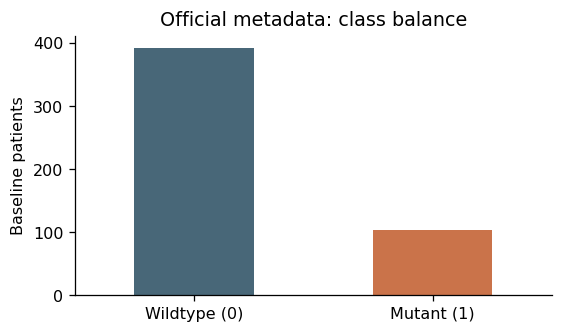

In [5]:
METADATA_URL = ('https://www.cancerimagingarchive.net/wp-content/uploads/'
                'UCSF-PDGM-metadata_v5.csv')
CHECKED_METADATA_SHA256 = 'afc1c23a0eb0597b56e603741e72f2308b4860281187cd3808e05b7a0116fd78'

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def json_write(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_name(path.name + '.tmp')
    temp.write_text(json.dumps(obj, indent=2, sort_keys=True, default=str))
    # Publish the finished file atomically rather than expose a partially written file.
    temp.replace(path)

def download_metadata(path):
    path = Path(path)
    if path.exists():
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    print('Downloading official metadata with the IDH labels.')
    try:
        response = requests.get(METADATA_URL, timeout=(15, 90))
        response.raise_for_status()
    except requests.RequestException as exc:
        raise RuntimeError(
            'The official metadata CSV could not be downloaded. Enable Kaggle '
            'Internet, or attach UCSF-PDGM-metadata_v5.csv and set METADATA_CSV '
            'to its actual path in section 2. Then restart and Run All.'
        ) from exc
    if len(response.content) < 1000 or 'text/html' in response.headers.get('Content-Type', ''):
        raise ValueError('The metadata endpoint did not return the expected CSV.')
    temp = path.with_name(path.name + '.part')
    temp.write_bytes(response.content)
    pd.read_csv(temp, nrows=1)  # Fail before publishing an unreadable download.
    # Publish the finished file atomically rather than expose a partially written file.
    temp.replace(path)

# Map old follow-up exam identifiers to the baseline patient identifier.
LEGACY_FOLLOWUPS = {315: 433, 278: 431, 175: 396,
                    138: 429, 181: 409, 289: 391}
ID_PATTERN = re.compile(r'UCSF[-_]PDGM[-_](\d{3,4})(_FU\d+d)?', re.I)

def parse_exam_id(value):
    match = ID_PATTERN.search(str(value))
    if match is None:
        raise ValueError(f'Unrecognized UCSF-PDGM identifier: {value!r}')
    number = int(match.group(1))
    followup = bool(match.group(2)) or number in LEGACY_FOLLOWUPS
    patient_number = LEGACY_FOLLOWUPS.get(number, number)
    return f'UCSF-PDGM-{patient_number:04d}', followup

def encode_idh(value):
    if pd.isna(value):
        return np.nan
    value = re.sub(r'\s+', ' ', str(value).strip().lower())
    if value in {'wildtype', 'wild-type', 'wild type', 'idh-wildtype'}:
        return 0
    if value in {'mutated (nos)', 'mutant', 'mutated', 'idh-mutant'}:
        return 1
    # Explicitly validated positive allele vocabulary in the official v5 CSV.
    positive_variants = {
        'idh1 p.r132h', 'idh1 p.r132c', 'idh1 p.r132g', 'idh1 p.r132s',
        'idh1 p.arg132his', 'idh2 p.r172k', 'idh2 p.arg172trp',
    }
    if value in positive_variants:
        return 1
    return np.nan  # A future or indeterminate label requires deliberate review.

def load_metadata(path):
    raw = pd.read_csv(path)
    raw.columns = raw.columns.str.strip()
    if not {'ID', 'IDH'}.issubset(raw.columns):
        raise ValueError('Expected official UCSF-PDGM clinical columns ID and IDH.')
    parsed = raw['ID'].map(parse_exam_id)
    raw['patient_id'] = parsed.map(lambda item: item[0])
    raw['is_followup'] = parsed.map(lambda item: item[1])
    raw['label'] = raw['IDH'].map(encode_idh)
    # Follow-ups and unknown labels are excluded before independent-patient splitting.
    reason = np.where(raw['is_followup'], 'repeat examination',
                      np.where(raw['label'].isna(), 'unknown IDH label', ''))
    excluded = raw.loc[reason != '', ['ID', 'IDH', 'patient_id']].copy()
    excluded['reason'] = reason[reason != '']
    cohort = raw.loc[reason == ''].copy()
    if cohort['patient_id'].duplicated().any():
        raise ValueError('Duplicate baseline patients remain; inspect metadata before splitting.')
    cohort['label'] = cohort['label'].astype(int)
    if set(cohort['label']) != {0, 1}:
        raise ValueError('Both molecular classes are required.')
    return raw, cohort.sort_values('patient_id').reset_index(drop=True), excluded


if RUN_EXTRACTION:
    download_metadata(METADATA_CSV)
    METADATA_SHA256 = sha256_file(METADATA_CSV)
    if METADATA_SHA256 != CHECKED_METADATA_SHA256:
        warnings.warn('Metadata bytes differ from the checked v5 snapshot; review the audit before training.')
    raw_metadata, metadata_cohort, excluded_metadata = load_metadata(METADATA_CSV)
    excluded_metadata.to_csv(WORK_ROOT / 'metadata_exclusions.csv', index=False)
    print(f'{len(raw_metadata)} examinations → {len(metadata_cohort)} labeled baseline patients')
    print('Metadata SHA256:', METADATA_SHA256)
    display(metadata_cohort.groupby('label').size().rename(index={0:'IDH wildtype', 1:'IDH mutant'}).to_frame('patients'))
    display(excluded_metadata)
    fig, ax = plt.subplots(figsize=(5, 3))
    metadata_cohort['label'].value_counts().sort_index().plot.bar(
        ax=ax, color=['#486778', '#ca734a'], rot=0)
    ax.set_xticklabels(['Wildtype (0)', 'Mutant (1)'])
    ax.set(xlabel='', ylabel='Baseline patients', title='Official metadata: class balance')
    plt.tight_layout()
    plt.show()


### Matching all three MRI contrasts to each patient

In [6]:
MODALITY_SUFFIXES = {
    'FLAIR': ('FLAIR_bias', 'FLAIR'),
    'T1c': ('T1c_bias', 'T1gad_bias', 'T1c', 'T1gad'),
    'T2': ('T2_bias', 'T2'),
}

def index_images(image_root, cohort, config):
    image_root = Path(image_root)
    if not image_root.exists():
        raise FileNotFoundError(f'Download/extract UCSF-PDGM and set IMAGE_ROOT. Missing: {image_root}')
    candidates = {}
    for path in sorted(image_root.rglob('*.nii*')):
        if not path.is_file() or not path.name.lower().endswith(('.nii', '.nii.gz')):
            continue
        if ID_PATTERN.search(path.name) is None:
            continue
        patient, followup = parse_exam_id(path.name)
        if followup:
            continue
        stem = re.sub(r'\.nii(\.gz)?$', '', path.name, flags=re.I)
        for modality in config.modalities:
            for rank, suffix in enumerate(MODALITY_SUFFIXES[modality]):
                if stem.lower().endswith('_' + suffix.lower()):
                    candidates.setdefault((patient, modality), []).append((rank, path.resolve()))
                    break
    rows, missing = [], []
    for source in cohort.to_dict('records'):
        row = {k: source[k] for k in ['patient_id', 'label']}
        row['grade'] = source.get('WHO CNS Grade', np.nan)
        row['age'] = source.get('Age at MRI', np.nan)
        row['sex'] = source.get('Sex', '')
        reasons = []
        for modality in config.modalities:
            options = candidates.get((source['patient_id'], modality), [])
            if not options:
                reasons.append(modality)
                continue
            # Suffix priority resolves supported variants consistently; ambiguous best files fail.
            rank = min(item[0] for item in options)
            best = sorted(set(path for r, path in options if r == rank))
            if len(best) != 1:
                raise ValueError(f'Ambiguous {source["patient_id"]} {modality}: {best}')
            row[modality] = str(best[0])
        if reasons:
            missing.append({'patient_id': source['patient_id'],
                            'reason': 'missing ' + ', '.join(reasons)})
        else:
            rows.append(row)
    missing = pd.DataFrame(missing, columns=['patient_id', 'reason'])
    return pd.DataFrame(rows), missing


## 4. Patient separation and descriptive data analysis

All slices from one person remain in one partition. With the expected 495-patient cohort, the default split produces **345 training, 75 validation, and 75 test patients**. Stratification approximately preserves the class proportions. Reference split files, when supplied, must match patient identities and labels.

Each group has a distinct role: training patients fit the head and select slice count; validation patients choose the final decision threshold; test patients assess the locked pipeline. Frozen encoding does not fit any parameters on these groups.

The added analysis below describes the cohort **before notebook normalization, cropping, or resizing**. Counts and exclusions describe cohort construction; more detailed demographics and raw image summaries use training patients. These descriptive outputs do not become model inputs or alter the split, fitting, or slice search.

In [7]:
def split_patients(cohort, config):
    if cohort['patient_id'].duplicated().any():
        raise ValueError('Split input must contain one row per patient.')
    # Reserve complete patients, not individual slices; stratify by the binary target.
    development, test = train_test_split(cohort, test_size=config.test_fraction, stratify=cohort['label'], random_state=config.seed)
    # Rescale the validation fraction because test patients are already removed.
    train, validation = train_test_split(development, test_size=config.validation_fraction / (1 - config.test_fraction), stratify=development['label'], random_state=config.seed + 1)
    split = {}
    for name, frame in [('train', train), ('validation', validation), ('test', test)]:
        split[name] = frame.sort_values('patient_id').reset_index(drop=True)
        assert set(split[name]['label']) == {0, 1}, f'Both classes required in {name}.'
    sets = {key: set(value['patient_id']) for key, value in split.items()}
    assert not (sets['train'] & sets['validation'] or sets['train'] & sets['test'] or sets['validation'] & sets['test'])
    assert set.union(*sets.values()) == set(cohort['patient_id'])
    return split

def load_reference_splits(directory, cohort):
    directory = Path(directory)
    result, seen = ({}, set())
    cohort_by_id = cohort.set_index('patient_id')
    for name in ('train', 'validation', 'test'):
        path = directory / f'{name}_patients.csv'
        saved = pd.read_csv(path, dtype={'patient_id': str})
        if not {'patient_id', 'label'}.issubset(saved.columns):
            raise ValueError(f'{path} must contain patient_id and label.')
        ids = saved['patient_id'].tolist()
        if len(ids) != len(set(ids)) or seen.intersection(ids):
            raise ValueError('Repeated patient or overlap in reference splits.')
        if not set(ids).issubset(cohort_by_id.index):
            raise ValueError('Reference splits contain patients missing from this cohort.')
        selected = cohort_by_id.loc[ids].reset_index()
        if not np.array_equal(selected['label'].to_numpy(), saved['label'].to_numpy()):
            raise ValueError('IDH labels differ from the reference experiment.')
        if set(selected['label']) != {0, 1}:
            raise ValueError(f'Both classes are required in {name}.')
        result[name] = selected.sort_values('patient_id').reset_index(drop=True)
        seen.update(ids)
    if seen != set(cohort_by_id.index):
        raise ValueError('The reference splits must cover exactly this cohort.')
    return result

if RUN_EXTRACTION:
    cohort, missing_images = index_images(IMAGE_ROOT, metadata_cohort, cfg)
    missing_images.to_csv(WORK_ROOT / 'missing_modalities.csv', index=False)
    if cohort.empty:
        raise ValueError('No complete patients matched IMAGE_ROOT.')
    if len(missing_images) and not cfg.allow_partial_cohort:
        raise ValueError('Missing MRI modalities. Inspect missing_modalities.csv; '
                         'use allow_partial_cohort=True only for a declared pilot cohort.')
    cohort = cohort.sort_values('patient_id').reset_index(drop=True)
    if cohort['label'].value_counts().min() < 10:
        raise ValueError('Insufficient patients per class for this split. Complete the dataset.')
    splits = (load_reference_splits(REFERENCE_SPLIT_DIR, cohort)
              if REFERENCE_SPLIT_DIR is not None else split_patients(cohort, cfg))
    assignment = {pid: name for name, frame in splits.items() for pid in frame['patient_id']}
    cohort['split'] = cohort['patient_id'].map(assignment)
    assert cohort['split'].notna().all()
    display(pd.crosstab(cohort['split'], cohort['label']).rename(columns={0:'wildtype', 1:'mutant'}))

    print('Reference splits:', REFERENCE_SPLIT_DIR if REFERENCE_SPLIT_DIR is not None else 'original seed/procedure')


label,wildtype,mutant
split,,
test,59,16
train,274,71
validation,59,16


Reference splits: original seed/procedure


### Data overview before image preprocessing

The cohort flow records exclusions and modality coverage. Class proportions explain why an always-wildtype predictor can achieve high accuracy. Training age, sex, and grade summaries describe potential population differences; these variables remain outside the classifier.

Raw NIfTI headers reveal volume dimensions, voxel spacing, orientation, and whether the three contrast grids agree. A deterministic sample of six training patients supplies raw intensity and nonzero axial-slice summaries without changing the images. The displayed slice counts are measured on source grids and may change after oblique resampling.

These volumes are already registered and skull-stripped by the source dataset; “raw” here means before this notebook's additional normalization, cropping, and resizing. Intensity percentiles have arbitrary units. The six-patient sample is a quality-control example, not a cohort-wide estimate of tissue signal.

,stage,rows
0,Official metadata examination rows,501
1,Excluded examination rows,6
2,Baseline patients with recognized IDH,495
3,Patients missing a required modality,0
4,Retained complete patients,495


,excluded_rows
reason,
repeat examination,6


,wildtype,mutant,total,mutant_fraction
split,,,,
train,274,71,345,0.205797
validation,59,16,75,0.213333
test,59,16,75,0.213333


Detailed demographics and raw image QC below use training patients only.


,missing_training_values
age,0
sex,0
grade,0


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
wildtype,274.0,62.036496,12.099047,21.0,54.0,62.5,71.0,94.0
mutant,71.0,39.563380,11.289353,19.0,32.0,38.0,46.0,71.0


,wildtype,mutant
sex,,
F,123,28
M,151,43


,wildtype,mutant
grade,,
2,5,34
3,10,20
4,259,17


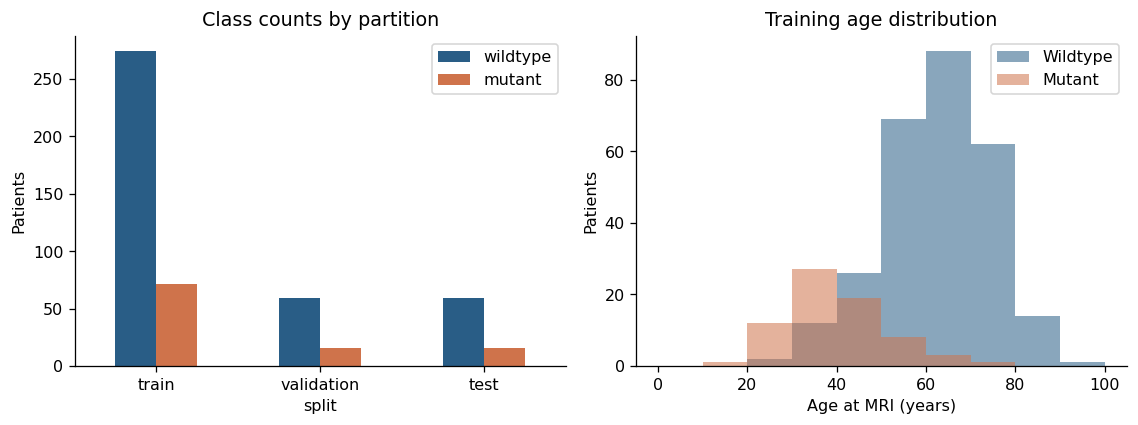

Raw training MRI headers:   0%|          | 0/345 [00:00<?, ?it/s]

spacing_x_mm             spacing_y_mm             spacing_z_mm  \
                  min median  max          min median  max          min   
modality                                                                  
FLAIR             1.0    1.0  1.0          1.0    1.0  1.0          1.0   
T1c               1.0    1.0  1.0          1.0    1.0  1.0          1.0   
T2                1.0    1.0  1.0          1.0    1.0  1.0          1.0   

                     source_file_MiB                      
         median  max             min    median       max  
modality                                                  
FLAIR       1.0  1.0        2.095828  2.994746  3.873263  
T1c         1.0  1.0        2.069837  2.875179  3.722119  
T2          1.0  1.0        2.066646  2.929713  3.778987

Training contrast headers not matching FLAIR: 0
FLAIR common shapes: [('(240, 240, 155)', 345)]
T1c common shapes: [('(240, 240, 155)', 345)]
T2 common shapes: [('(240, 240, 155)', 345)]


,patient_id,modality,nonfinite_voxels,nonzero_fraction,nonempty_source_axial_slices,raw_p01,raw_median,raw_p99
0,UCSF-PDGM-0077,FLAIR,0,0.187471,144,174.402893,990.827515,2262.881836
1,UCSF-PDGM-0077,T1c,0,0.187471,144,681.824951,1987.542114,5517.611392
2,UCSF-PDGM-0077,T2,0,0.187471,144,128.241165,578.699829,1983.048340
3,UCSF-PDGM-0132,FLAIR,0,0.182328,145,109.676666,990.414673,2015.922852
4,UCSF-PDGM-0132,T1c,0,0.182328,145,715.994080,1886.627808,4660.253535
5,UCSF-PDGM-0132,T2,0,0.182328,145,70.738861,461.998230,1517.559448
6,UCSF-PDGM-0147,FLAIR,0,0.170976,143,213.991623,1199.528687,3529.235840
7,UCSF-PDGM-0147,T1c,0,0.170976,143,650.807068,2246.040283,4931.055664
8,UCSF-PDGM-0147,T2,0,0.170976,143,128.771606,589.107056,2443.505615
9,UCSF-PDGM-0157,FLAIR,0,0.162930,133,188.031769,1318.721924,2360.837646


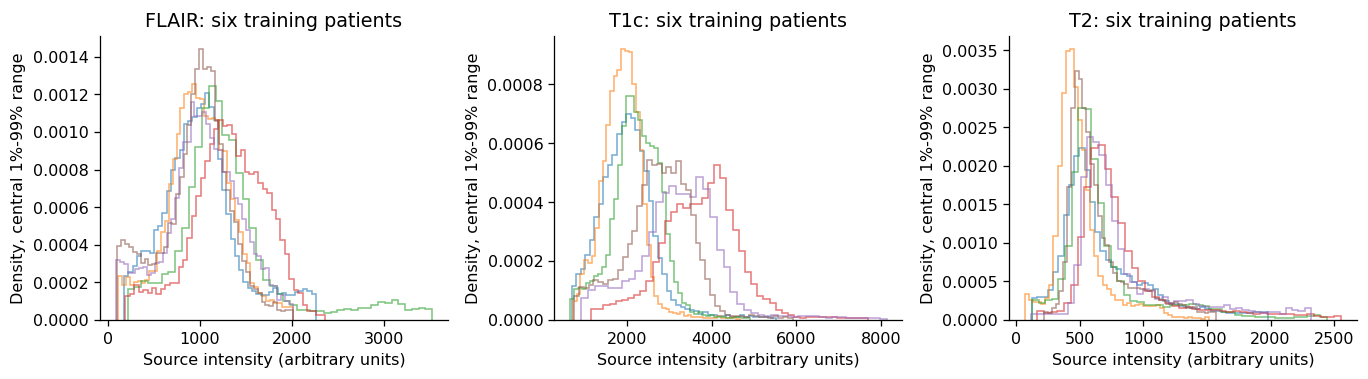

Descriptive reports saved: /kaggle/working/radiogenomics_frozen/idh_dinov2_auto_slices_v1/presentation_data_analysis


In [8]:
# Descriptive analysis only: no predictor inputs, configuration, or split assignments change.
def presentation_data_overview(frame, raw, excluded, missing, config, output_dir):
    from collections import Counter
    root = Path(output_dir)
    root.mkdir(parents=True, exist_ok=True)
    flow = pd.DataFrame([
        {'stage': 'Official metadata examination rows', 'rows': len(raw)},
        {'stage': 'Excluded examination rows', 'rows': len(excluded)},
        {'stage': 'Baseline patients with recognized IDH', 'rows': len(metadata_cohort)},
        {'stage': 'Patients missing a required modality', 'rows': len(missing)},
        {'stage': 'Retained complete patients', 'rows': len(frame)},
    ])
    flow.to_csv(root / 'cohort_flow.csv', index=False)
    display(flow)
    if len(excluded):
        display(excluded['reason'].value_counts().rename('excluded_rows').to_frame())
    counts = pd.crosstab(frame['split'], frame['label']).reindex(
        index=['train', 'validation', 'test'], columns=[0, 1], fill_value=0)
    counts.columns = ['wildtype', 'mutant']
    counts['total'] = counts.sum(axis=1)
    counts['mutant_fraction'] = counts['mutant'] / counts['total']
    counts.to_csv(root / 'partition_class_counts.csv')
    display(counts)
    train = frame.loc[frame['split'].eq('train')].copy()
    print('Detailed demographics and raw image QC below use training patients only.')
    missingness = train[['age', 'sex', 'grade']].replace(r'^\s*$', np.nan, regex=True).isna().sum()
    missingness.to_frame('missing_training_values').to_csv(root / 'metadata_missingness.csv')
    display(missingness.to_frame('missing_training_values'))
    age = pd.to_numeric(train['age'], errors='coerce')
    age_summary = train.assign(age_numeric=age).groupby('label')['age_numeric'].describe()
    age_summary.to_csv(root / 'training_age_by_idh.csv')
    display(age_summary.rename(index={0: 'wildtype', 1: 'mutant'}))
    for column in ['sex', 'grade']:
        values = train[column].fillna('Missing').astype(str).replace(r'^\s*$', 'Missing', regex=True)
        table = pd.crosstab(values, train['label']).reindex(columns=[0, 1], fill_value=0)
        table.columns = ['wildtype', 'mutant']
        table.to_csv(root / f'training_{column}_by_idh.csv')
        display(table)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    counts[['wildtype', 'mutant']].plot.bar(ax=axes[0], rot=0, color=['#295d86', '#cf734b'])
    axes[0].set(title='Class counts by partition', ylabel='Patients')
    for label, name, color in [(0, 'Wildtype', '#295d86'), (1, 'Mutant', '#cf734b')]:
        axes[1].hist(age[train['label'].eq(label)].dropna(), bins=np.arange(0, 101, 10),
                     alpha=.55, label=name, color=color)
    axes[1].set(title='Training age distribution', xlabel='Age at MRI (years)', ylabel='Patients')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(root / 'cohort_overview.png', dpi=150)
    plt.show()

    # Header access reads geometry without loading every voxel array into memory.
    header_rows = []
    for row in tqdm(train.to_dict('records'), desc='Raw training MRI headers', leave=False):
        reference = None
        for modality in config.modalities:
            image = nib.load(row[modality])
            if reference is None:
                reference = image
            matched = (image.shape == reference.shape
                       and np.allclose(image.affine, reference.affine, rtol=0, atol=1e-3))
            spacing = image.header.get_zooms()[:3]
            header_rows.append({'patient_id': row['patient_id'], 'modality': modality,
                'shape': str(tuple(image.shape)), 'orientation': ''.join(nib.aff2axcodes(image.affine)),
                'spacing_x_mm': float(spacing[0]), 'spacing_y_mm': float(spacing[1]),
                'spacing_z_mm': float(spacing[2]), 'grid_matches_FLAIR': bool(matched),
                'source_file_MiB': Path(row[modality]).stat().st_size / (1024 ** 2)})
    headers = pd.DataFrame(header_rows)
    headers.to_csv(root / 'training_raw_mri_headers.csv', index=False)
    display(headers.groupby('modality')[['spacing_x_mm', 'spacing_y_mm',
        'spacing_z_mm', 'source_file_MiB']].agg(['min', 'median', 'max']))
    print('Training contrast headers not matching FLAIR:', int((~headers['grid_matches_FLAIR']).sum()))
    for modality in config.modalities:
        print(modality, 'common shapes:', Counter(headers.loc[headers.modality.eq(modality), 'shape']).most_common(3))

    # Limit voxel-level audit to six reproducibly sampled training patients.
    sample = train.sample(n=min(6, len(train)), random_state=config.seed).sort_values('patient_id')
    intensity_rows = []
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
    audit_rng = np.random.default_rng(config.seed + 77)  # Does not reseed training randomness.
    for row in sample.to_dict('records'):
        for channel, modality in enumerate(config.modalities):
            image = nib.as_closest_canonical(nib.load(row[modality]))
            array = image.get_fdata(dtype=np.float32)
            finite = np.isfinite(array)
            support = finite & (np.abs(array) > 1e-8)
            values = array[support]
            q = np.percentile(values, [1, 50, 99]) if len(values) else [np.nan] * 3
            intensity_rows.append({'patient_id': row['patient_id'], 'modality': modality,
                'nonfinite_voxels': int((~finite).sum()), 'nonzero_fraction': float(support.mean()),
                'nonempty_source_axial_slices': int(support.any(axis=(0, 1)).sum()),
                'raw_p01': float(q[0]), 'raw_median': float(q[1]), 'raw_p99': float(q[2])})
            if len(values):
                sampled = audit_rng.choice(values, size=min(20000, len(values)), replace=False)
                # Plot central intensity range; retain unclipped percentiles in the table.
                central = sampled[(sampled >= q[0]) & (sampled <= q[2])]
                if len(central):
                    axes[channel].hist(central, bins=45, density=True, histtype='step',
                                       alpha=.6, label=row['patient_id'])
            del array, values, support
    intensity = pd.DataFrame(intensity_rows)
    intensity.to_csv(root / 'sample_raw_intensity_audit.csv', index=False)
    display(intensity)
    for axis, modality in zip(axes, config.modalities):
        axis.set(title=f'{modality}: six training patients', xlabel='Source intensity (arbitrary units)',
                 ylabel='Density, central 1%-99% range')
    fig.tight_layout()
    fig.savefig(root / 'sample_raw_intensity_distributions.png', dpi=150)
    plt.show()
    print('Descriptive reports saved:', root)


if RUN_EXTRACTION:
    presentation_data_overview(cohort, raw_metadata, excluded_metadata, missing_images,
                               cfg, SEARCH_ROOT / 'presentation_data_analysis')
else:
    print('Raw-data overview skipped in feature-pack mode; no source MRI access is required.')

## 5. Frozen DINOv2: from an MRI plane to a representation

An input is a tensor of shape **(slices in batch, 3, 224, 224)**. The channels are FLAIR, T1c, and T2 at the same anatomical position. They replace the RGB channels expected by the natural-image pretrained encoder; this is a domain adaptation assumption, not evidence that MRI and photographs have the same distribution.

DINOv2-Small uses 14 × 14 patches: a 224 × 224 image yields 256 patch tokens plus a class token. Its transformer has 12 blocks and 6 attention heads per block. Token-level self-attention uses learned Q, K, and V projections to relate patches. This differs from the later slice-pooling attention head.

The encoder returns a **384-number class-token vector per slice**, and also saves mean patch vectors for later experiments. `requires_grad_(False)` prevents weight updates; evaluation mode controls training-specific layer behavior; inference mode avoids gradient tracking. A checksum confirms that extraction leaves the weights unchanged.

The original pretrained channel means and standard deviations are retained after per-volume MRI normalization. Freezing makes extraction reusable, but may limit adaptation to MRI-specific features.

In [9]:
def model_digest(model):
    digest = hashlib.sha256()
    for name, tensor in sorted(model.state_dict().items()):
        digest.update(name.encode())
        digest.update(str(tuple(tensor.shape)).encode())
        digest.update(tensor.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()


class FrozenDINOv2(nn.Module):
    def __init__(self, config, encoder=None):
        super().__init__()
        # encoder injection supports local software checks; normal runs load the pinned checkpoint.
        self.encoder = encoder if encoder is not None else Dinov2Model.from_pretrained(
            config.model_id, revision=config.model_revision,
            cache_dir=str(PRETRAINED_CACHE), use_safetensors=True, token=HF_ACCESS_TOKEN,
        )
        # Frozen parameters never receive optimization updates.
        self.encoder.requires_grad_(False)
        self.register_buffer('input_mean', torch.tensor([.485, .456, .406]).view(1, 3, 1, 1))
        self.register_buffer('input_std', torch.tensor([.229, .224, .225]).view(1, 3, 1, 1))
        self.eval()

    def train(self, mode=True):
        # Extraction remains deterministic even if an external caller invokes train().
        super().train(False)
        return self

    @torch.inference_mode()
    def forward(self, images):
        if images.ndim != 4 or images.shape[1] != 3:
            raise ValueError('Expected a slice batch of shape (N, 3, H, W).')
        patch = self.encoder.config.patch_size
        if images.shape[-2] % patch or images.shape[-1] % patch:
            raise ValueError('Input dimensions must be divisible by the patch size.')
        # Input: N x 3 x H x W. Output: N x (1 + patch tokens) x 384.
        hidden = self.encoder(pixel_values=(images-self.input_mean)/self.input_std,
                              return_dict=True).last_hidden_state
        # Token 0 summarizes the slice; remaining tokens describe image patches.
        return hidden[:, 0].float(), hidden[:, 1:].float().mean(dim=1)


def extraction_identity(config, model, device):
    precision = 'cuda_float16_autocast' if config.use_mixed_precision and device.type == 'cuda' else 'float32'
    identity = {
        'model_id': config.model_id, 'model_revision': config.model_revision,
        'model_state_sha256': model_digest(model),
        'feature_dimension': int(model.encoder.config.hidden_size),
        'patch_size': int(model.encoder.config.patch_size),
        'modalities': list(config.modalities), 'image_size': config.image_size,
        'crop_margin_voxels': config.crop_margin_voxels,
        'extraction_version': config.extraction_version,
        'slice_rule': 'every nonempty axial plane in the working RAS grid',
        'normalization': 'per-volume nonzero 1st/99th percentile to [0,1], then pretrained channel mean/std',
        'precision': precision, 'saved_feature_dtype': 'float32',
        'software': VERSIONS,
    }
    # The signature identifies model, preprocessing, software, and precision together.
    signature = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
    return signature, identity


def initialize_extraction(cohort, config, model, device, run_root, metadata_sha, dataset_source):
    root = Path(run_root)
    root.mkdir(parents=True, exist_ok=True)
    signature, identity = extraction_identity(config, model, device)
    stable = {
        'feature_signature': signature,
        'patients': cohort[['patient_id', 'label', 'split']].sort_values('patient_id').to_dict('records'),
        'metadata_sha256': metadata_sha,
    }
    marker = root / 'run_identity.json'
    if marker.exists() and json.loads(marker.read_text())['identity'] != stable:
        raise ValueError('Feature settings, model, software, cohort, or splits changed. Use a new run_name.')
    json_write(marker, {'identity': stable, 'feature_identity': identity})
    json_write(root / 'extraction_config.json', asdict(config))
    json_write(root / 'dataset_source.json', dataset_source)
    json_write(root / 'software_versions.json', VERSIONS)
    cohort.to_csv(root / 'source_manifest.csv', index=False)
    (root / 'features').mkdir(exist_ok=True)
    return signature, identity


if RUN_EXTRACTION:
    download_with_retries(repo_id=cfg.model_id, revision=cfg.model_revision,
                          allow_patterns=['config.json', 'model.safetensors'],
                          cache_dir=str(PRETRAINED_CACHE), max_workers=1, token=HF_ACCESS_TOKEN)
    encoder = FrozenDINOv2(cfg).to(DEVICE).eval()
    assert sum(p.numel() for p in encoder.parameters() if p.requires_grad) == 0
    FEATURE_SIGNATURE, FEATURE_IDENTITY = initialize_extraction(
        cohort, cfg, encoder, DEVICE, RUN_ROOT, METADATA_SHA256, DATASET_SOURCE)
    ENCODER_BEFORE = FEATURE_IDENTITY['model_state_sha256']
    print('Trainable parameters: 0')
    print('Features per slice:', FEATURE_IDENTITY['feature_dimension'])
    print('Effective precision:', FEATURE_IDENTITY['precision'])


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Trainable parameters: 0
Features per slice: 384
Effective precision: cuda_float16_autocast


## 6. Image preparation: geometry, intensity, and slice eligibility

Voxel indices describe array locations; an affine matrix maps them to physical coordinates in millimetres. Canonical orientation standardizes axis directions. Matching grids across contrasts is required, but a matching header alone cannot prove anatomical registration quality.

Each modality is independently normalized using its nonzero-voxel 1st and 99th percentiles. Values are clipped into [0, 1]. This reduces the effect of extreme intensities without fitting population statistics. Raw MRI intensities have arbitrary units and should not be interpreted as comparable physical quantities across patients.

Oblique volumes are resampled to one shared axial grid. Nonzero support across modalities defines the crop and eligible slices. **Nonempty does not mean tumor-containing:** the support rule uses no tumor mask or molecular label.

Cropping removes empty margins. Letterboxing resizes according to physical aspect ratio and adds padding to reach 224 × 224, avoiding independent stretching of width and height. Resizing can lose small details; the later preview compares the working grid with the actual encoder input.

In [10]:
def load_canonical_volume(path):
    image = nib.as_closest_canonical(nib.load(str(path)))
    if len(image.shape) != 3:
        raise ValueError(f'Expected 3-D NIfTI, got {image.shape}: {path}')
    array = image.get_fdata(dtype=np.float32)
    if not np.isfinite(array).all():
        raise ValueError(f'Nonfinite voxel intensity: {path}')
    zooms = np.asarray(image.header.get_zooms()[:3], dtype=float)
    if not np.isfinite(zooms).all() or (zooms <= 0).any():
        raise ValueError(f'Invalid voxel spacing: {path}')
    return (image, array)

def normalize_mri(array):
    support = np.abs(array) > 1e-08
    if support.sum() < 100:
        raise ValueError('Too few nonzero brain voxels.')
    # Percentiles are computed within this volume; no test-cohort statistics are fitted.
    low, high = np.percentile(array[support], [1, 99])
    if high - low < 1e-06:
        raise ValueError('Constant or degenerate MRI volume.')
    result = np.zeros_like(array, dtype=np.float32)
    result[support] = np.clip((array[support] - low) / (high - low), 0, 1)
    return (result, support)

def letterbox(tensor, size, pixel_spacing):
    height, width = tensor.shape[-2:]
    # Use millimetre aspect ratio so anisotropic pixels do not stretch the anatomy.
    physical_h, physical_w = (height * pixel_spacing[0], width * pixel_spacing[1])
    scale = size / max(physical_h, physical_w)
    new_h = max(1, min(size, round(physical_h * scale)))
    new_w = max(1, min(size, round(physical_w * scale)))
    tensor = F.interpolate(tensor, size=(new_h, new_w), mode='bilinear', align_corners=False, antialias=True)
    dh, dw = (size - new_h, size - new_w)
    return F.pad(tensor, (dw // 2, dw - dw // 2, dh // 2, dh - dh // 2))

def prepare_volume(paths, config):
    arrays, masks = [], []
    reference = None
    for modality in config.modalities:
        image, raw = load_canonical_volume(paths[modality])
        if reference is None:
            reference = image
        elif image.shape != reference.shape or not np.allclose(image.affine, reference.affine, rtol=0, atol=1e-3):
            raise ValueError(f'{modality} grid differs from FLAIR; explicit registration is required.')
        normalized, support = normalize_mri(raw)
        arrays.append(normalized)
        masks.append(support)
    support = np.logical_or.reduce(masks)
    original_shape = list(reference.shape)
    original_affine = reference.affine.copy()
    # Affine columns encode voxel-axis directions in physical space.
    directions = reference.affine[:3, :3] / np.linalg.norm(reference.affine[:3, :3], axis=0)
    oblique = bool(np.max(np.abs(directions-np.diag(np.diag(directions)))) > 1e-4)
    # Resample every contrast to the same axial grid; use nearest-neighbor for support.
    if oblique:
        images = [nib.Nifti1Image(a, reference.affine) for a in arrays]
        target = resample_to_output(images[0], voxel_sizes=reference.header.get_zooms()[:3], order=1)
        grid = (target.shape, target.affine)
        arrays = [target.get_fdata(dtype=np.float32)] + [
            resample_from_to(im, grid, order=1).get_fdata(dtype=np.float32) for im in images[1:]]
        support = resample_from_to(nib.Nifti1Image(support.astype(np.uint8), reference.affine),
                                   grid, order=0).get_fdata() > 0
        reference = target
    # Nonzero support locates brain extent, not tumor extent.
    occupied = [np.flatnonzero(support.any(axis=tuple(j for j in range(3) if j != axis)))
                for axis in range(3)]
    if any(len(values) == 0 for values in occupied):
        raise ValueError('No nonempty image support remains.')
    margin = config.crop_margin_voxels
    starts = [max(0, int(v[0])-margin) for v in occupied]
    stops = [min(support.shape[i], int(v[-1])+1+margin) for i, v in enumerate(occupied)]
    indices = occupied[2].astype(np.int32)
    if len(indices) < 2:
        raise ValueError('Too few nonempty axial slices.')
    zooms = [float(v) for v in reference.header.get_zooms()[:3]]
    centers = np.column_stack([
        np.full(len(indices), (starts[0]+stops[0]-1)/2),
        np.full(len(indices), (starts[1]+stops[1]-1)/2), indices])
    # Physical slice coordinates remain meaningful even after a grid change.
    z_mm = nib.affines.apply_affine(reference.affine, centers)[:, 2]
    fractions = ((z_mm-z_mm.min())/(z_mm.max()-z_mm.min())).astype(np.float32)
    area = support.mean(axis=(0, 1))[indices].astype(np.float32)
    qc = {
        'orientation': ''.join(nib.aff2axcodes(reference.affine)),
        'source_shape_canonical': original_shape, 'source_affine_canonical': original_affine.tolist(),
        'working_shape': list(reference.shape), 'working_affine': reference.affine.tolist(),
        'resampled_oblique': oblique, 'voxel_spacing': zooms,
        'crop_starts': starts, 'crop_stops': stops,
        'nonempty_slices': int(len(indices)),
    }
    return {'arrays': arrays, 'indices': indices, 'z_mm': z_mm,
            'fractions': fractions, 'area': area, 'qc': qc}


def image_batch(prepared, positions, config):
    indices = prepared['indices'][np.asarray(positions, dtype=int)]
    starts, stops = prepared['qc']['crop_starts'], prepared['qc']['crop_stops']
    # Reorder each axial array into N x H x W, then stack contrasts as N x 3 x H x W.
    stacked = np.stack([
        array[starts[0]:stops[0], starts[1]:stops[1], :][:, :, indices].transpose(2, 1, 0)
        for array in prepared['arrays']], axis=1)
    zooms = prepared['qc']['voxel_spacing']
    images = letterbox(torch.from_numpy(stacked.copy()), config.image_size, (zooms[1], zooms[0]))
    images = images.clamp(0, 1)
    if images.shape != (len(indices), 3, config.image_size, config.image_size) or not torch.isfinite(images).all():
        raise ValueError('Invalid slice batch after preprocessing.')
    return images


## 7. Feature caching and experiment provenance

The expensive encoder runs once per eligible slice. Numerical arrays are saved in `.npz` files; JSON stores settings and provenance; CSV manifests link patients, labels, partitions, and saved files. The cache is **saved computation**, not an additional model.

Feature signatures identify the encoder, preprocessing, and precision. Source checksums identify MRI bytes. A file can be reused only when these identities and its dimensions agree. Temporary writes followed by replacement reduce the chance of publishing partial files.

Feature arrays include both class-token and mean-patch representations, physical slice positions, and support measurements. Caching all slices allows several sampling counts without repeating DINOv2. It also trades disk usage for less repeated computation.

Completed patients survive an interruption. A whole-cohort completion marker is written only after all feature files pass checks and the frozen encoder checksum remains unchanged.

In [11]:
FEATURE_FIELDS = ('cls_features', 'patch_mean_features', 'slice_indices',
                  'slice_z_mm', 'slice_fraction', 'nonzero_area_fraction',
                  'patient_id', 'feature_signature', 'source_signature')


def validate_feature_arrays(data, expected_dimension=None):
    if set(FEATURE_FIELDS)-set(data):
        raise ValueError('Missing feature arrays.')
    cls, patch = data['cls_features'], data['patch_mean_features']
    if cls.ndim != 2 or patch.shape != cls.shape or cls.shape[0] < 2:
        raise ValueError('Invalid embedding dimensions.')
    if expected_dimension is not None and cls.shape[1] != expected_dimension:
        raise ValueError('Unexpected feature dimension.')
    if cls.dtype != np.float32 or patch.dtype != np.float32:
        raise ValueError('Expected float32 feature arrays.')
    if not np.isfinite(cls).all() or not np.isfinite(patch).all():
        raise ValueError('Nonfinite embedding values.')
    n = len(cls)
    for name in ('slice_indices', 'slice_z_mm', 'slice_fraction', 'nonzero_area_fraction'):
        if data[name].shape != (n,) or not np.isfinite(data[name]).all():
            raise ValueError(f'Invalid {name}.')
    if not np.all(np.diff(data['slice_indices']) > 0) or not np.all(np.diff(data['slice_z_mm']) > 0):
        raise ValueError('Slice positions must be unique and increasing.')
    if np.any(data['slice_fraction'] < 0) or np.any(data['slice_fraction'] > 1):
        raise ValueError('Slice fractions outside [0, 1].')
    if np.any(data['nonzero_area_fraction'] <= 0) or np.any(data['nonzero_area_fraction'] > 1):
        raise ValueError('Invalid nonzero slice support.')
    for name in ('patient_id', 'feature_signature', 'source_signature'):
        if np.asarray(data[name]).shape != ():
            raise ValueError(f'Invalid scalar {name}.')
    return n


def read_feature_arrays(path):
    with np.load(path, allow_pickle=False) as stored:
        return {key: stored[key] for key in stored.files}


# Hash source bytes so identical files can be relocated without changing their identity.
def patient_source_identity(row, config):
    sources = {modality: {'sha256': sha256_file(row[modality]),
                          'bytes': Path(row[modality]).stat().st_size}
               for modality in config.modalities}
    signature = hashlib.sha256(json.dumps(sources, sort_keys=True).encode()).hexdigest()
    return signature, sources


@torch.inference_mode()
# Process slice batches to bound device memory while retaining every eligible slice.
def encode_volume(prepared, model, config, device):
    if model.training or any(p.requires_grad for p in model.parameters()):
        raise ValueError('The DINOv2 encoder must be frozen and in evaluation mode.')
    cls_parts, patch_parts = [], []
    count = len(prepared['indices'])
    for start in range(0, count, config.slice_batch_size):
        positions = np.arange(start, min(start+config.slice_batch_size, count))
        images = image_batch(prepared, positions, config).to(device)
        use_amp = config.use_mixed_precision and device.type == 'cuda'
        context = torch.autocast(device_type='cuda', dtype=torch.float16) if use_amp else contextlib.nullcontext()
        with context:
            cls, patch = model(images)
        cls_parts.append(cls.cpu().numpy().astype(np.float32, copy=True))
        patch_parts.append(patch.cpu().numpy().astype(np.float32, copy=True))
    return np.concatenate(cls_parts), np.concatenate(patch_parts)


def extract_patient(row, model, config, device, run_root, feature_signature):
    root = Path(run_root)
    patient_id = str(row['patient_id'])
    if re.fullmatch(r'UCSF-PDGM-\d{4}', patient_id) is None:
        raise ValueError('Unexpected patient ID format.')
    relative = Path('features') / f'{patient_id}.npz'
    path = root / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    sidecar = path.with_suffix('.json')
    source_signature, sources = patient_source_identity(row, config)
    dimension = int(model.encoder.config.hidden_size)
    if path.exists() and sidecar.exists():
        try:
            meta = json.loads(sidecar.read_text())
            if (meta['feature_signature'] == feature_signature and meta['source_signature'] == source_signature
                    and meta['feature_sha256'] == sha256_file(path)):
                data = read_feature_arrays(path)
                n = validate_feature_arrays(data, dimension)
                if (str(data['patient_id'].item()) == patient_id
                        and str(data['feature_signature'].item()) == feature_signature
                        and str(data['source_signature'].item()) == source_signature):
                    return {'patient_id': patient_id, 'feature_file': relative.as_posix(),
                            'n_slices': n, 'feature_dim': dimension, 'cache_status': 'reused',
                            'feature_sha256': meta['feature_sha256'], 'feature_bytes': path.stat().st_size}
        except (OSError, ValueError, KeyError, EOFError, zipfile.BadZipFile):
            pass
        warnings.warn(f'Rebuilding incomplete, changed, or corrupt features for {patient_id}.')
    prepared = prepare_volume(row, config)
    cls, patch = encode_volume(prepared, model, config, device)
    data = {
        'cls_features': cls, 'patch_mean_features': patch,
        'slice_indices': prepared['indices'], 'slice_z_mm': prepared['z_mm'],
        'slice_fraction': prepared['fractions'], 'nonzero_area_fraction': prepared['area'],
        'patient_id': np.asarray(patient_id), 'feature_signature': np.asarray(feature_signature),
        'source_signature': np.asarray(source_signature),
    }
    n = validate_feature_arrays(data, dimension)
    temp = path.with_name(path.name+'.part')
    with temp.open('wb') as stream:
        # Save numerical feature arrays and coordinates; JSON stores the accompanying provenance.
        np.savez_compressed(stream, **data)
    temp.replace(path)
    feature_sha = sha256_file(path)
    json_write(sidecar, {
        'patient_id': patient_id, 'feature_signature': feature_signature,
        'source_signature': source_signature, 'sources': sources,
        'feature_sha256': feature_sha, 'qc': prepared['qc'],
    })
    return {'patient_id': patient_id, 'feature_file': relative.as_posix(),
            'n_slices': n, 'feature_dim': dimension, 'cache_status': 'extracted',
            'feature_sha256': feature_sha, 'feature_bytes': path.stat().st_size}


# The complete marker is published only after every patient passes validation.
def extract_cohort(cohort, model, config, device, run_root, feature_signature, expected_model_digest):
    root = Path(run_root)
    complete = root / 'extraction_complete.json'
    complete.unlink(missing_ok=True)
    results = []
    started = time.perf_counter()
    progress = tqdm(cohort.to_dict('records'), desc='Frozen DINOv2: patients')
    for row in progress:
        try:
            result = extract_patient(row, model, config, device, root, feature_signature)
        except Exception as exc:
            pd.DataFrame([{'patient_id': row['patient_id'], 'error': str(exc)}]).to_csv(
                root / 'extraction_error.csv', index=False)
            raise RuntimeError(f'Extraction stopped at {row["patient_id"]}. '
                               'Completed patient files are retained; inspect extraction_error.csv.') from exc
        results.append(result)
        progress.set_postfix(patient=row['patient_id'], slices=result['n_slices'], cache=result['cache_status'])
    features = pd.DataFrame(results)
    expected_ids = set(cohort['patient_id'])
    if set(features['patient_id']) != expected_ids or features['patient_id'].duplicated().any():
        raise ValueError('Extracted patient IDs do not match the cohort.')
    if model_digest(model) != expected_model_digest or any(p.requires_grad or p.grad is not None for p in model.parameters()):
        raise RuntimeError('Encoder weights or gradient state changed during extraction.')
    table = cohort[['patient_id', 'label', 'split', 'age', 'sex', 'grade']].merge(
        features, on='patient_id', how='left', validate='one_to_one')
    table.to_csv(root / 'patient_manifest.csv', index=False)
    for name in ('train', 'validation', 'test'):
        table.loc[table['split'] == name].to_csv(root / f'{name}_patients.csv', index=False)
    slice_rows = []
    for record in table.to_dict('records'):
        data = read_feature_arrays(root / record['feature_file'])
        for i in range(record['n_slices']):
            slice_rows.append({
                'patient_id': record['patient_id'], 'split': record['split'], 'feature_row': i,
                'slice_index': int(data['slice_indices'][i]), 'slice_z_mm': float(data['slice_z_mm'][i]),
                'slice_fraction': float(data['slice_fraction'][i]),
                'nonzero_area_fraction': float(data['nonzero_area_fraction'][i]),
            })
    pd.DataFrame(slice_rows).to_csv(root / 'slice_manifest.csv', index=False)
    summary = {
        'patients': len(table), 'slices': int(table['n_slices'].sum()),
        'feature_dimension': int(table['feature_dim'].iloc[0]),
        'feature_bytes': int(table['feature_bytes'].sum()),
        'patients_reused': int((table['cache_status'] == 'reused').sum()),
        'seconds_this_run': time.perf_counter()-started,
        'encoder_frozen_verified': True, 'encoder_state_sha256': expected_model_digest,
        'feature_signature': feature_signature,
        'labels_used_by_encoder': False, 'test_predictions_computed': False,
        'patient_manifest_sha256': sha256_file(root / 'patient_manifest.csv'),
        'slice_manifest_sha256': sha256_file(root / 'slice_manifest.csv'),
    }
    (root / 'extraction_error.csv').unlink(missing_ok=True)
    json_write(complete, summary)
    return table, summary


if RUN_EXTRACTION:
    feature_manifest, extraction_summary = extract_cohort(
        cohort, encoder, cfg, DEVICE, RUN_ROOT, FEATURE_SIGNATURE, ENCODER_BEFORE)
    display(pd.Series(extraction_summary, name='Extraction summary').to_frame())
    display(feature_manifest[['patient_id', 'split', 'n_slices', 'feature_dim', 'cache_status']].head())
    print('Feature extraction complete. Classifier selection starts below.')
    del encoder
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


Frozen DINOv2: patients:   0%|          | 0/495 [00:00<?, ?it/s]

,Extraction summary
patients,495
slices,69853
feature_dimension,384
feature_bytes,200837682
patients_reused,0
seconds_this_run,834.187153
encoder_frozen_verified,True
encoder_state_sha256,e837f69e1b0a4aa08e9fc9db90e1053037ea05146b33b9...
feature_signature,72c5ec2001db0b178448405a657f0b621709d5d08cba50...
labels_used_by_encoder,False


,patient_id,split,n_slices,feature_dim,cache_status
0,UCSF-PDGM-0004,train,133,384,extracted
1,UCSF-PDGM-0005,train,133,384,extracted
2,UCSF-PDGM-0007,train,141,384,extracted
3,UCSF-PDGM-0008,test,134,384,extracted
4,UCSF-PDGM-0009,train,124,384,extracted


Feature extraction complete. Classifier selection starts below.


## 8. Visual quality control: working MRI versus encoder input

The left column displays one training patient's normalized MRI slice on the working grid. The right column displays the actual cropped and resized encoder input for the same position and contrast.

Inspect orientation, alignment, cropping, anatomical distortion, and whether useful regions are visibly lost. This checks processing integrity; an image alone does not reveal the true molecular label or establish prediction quality. The preview is not a tumor segmentation.

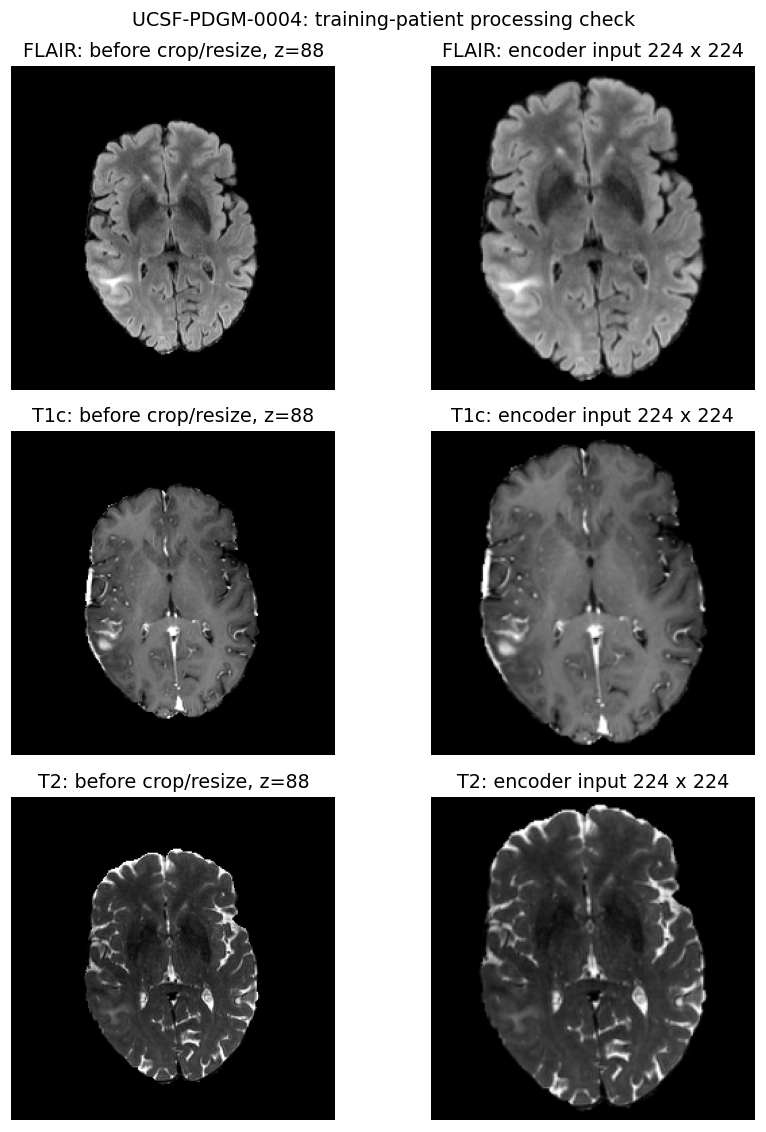

Saved CLS and patch-mean features separately; no patient pooling was applied.


In [12]:
def preview_patient(row, config, run_root):
    prepared = prepare_volume(row, config)
    position = len(prepared['indices']) // 2
    z = int(prepared['indices'][position])
    processed = image_batch(prepared, [position], config)[0].numpy()
    fig, axes = plt.subplots(3, 2, figsize=(8, 10))
    for i, modality in enumerate(config.modalities):
        axes[i, 0].imshow(prepared['arrays'][i][:, :, z].T, cmap='gray', vmin=0, vmax=1, origin='lower')
        axes[i, 1].imshow(processed[i], cmap='gray', vmin=0, vmax=1, origin='lower')
        axes[i, 0].set_title(f'{modality}: before crop/resize, z={z}')
        axes[i, 1].set_title(f'{modality}: encoder input {config.image_size} x {config.image_size}')
        for ax in axes[i]:
            ax.axis('off')
    fig.suptitle(f'{row["patient_id"]}: training-patient processing check')
    fig.tight_layout()
    fig.savefig(Path(run_root) / 'training_input_preview.png', dpi=130, bbox_inches='tight')
    plt.show()


if RUN_EXTRACTION:
    preview_patient(cohort.loc[cohort['split'] == 'train'].iloc[0], cfg, RUN_ROOT)
    print('Saved CLS and patch-mean features separately; no patient pooling was applied.')


## 9. Controlled sampling and variable-length patient bags

Every candidate uses the same **5%–95% interval of the nonempty brain extent**. This holds anatomical coverage approximately fixed while varying sampling density. Selection uses physical positions and neither IDH labels nor tumor masks.

For a requested count k, the sampler chooses evenly spaced eligible positions without duplicating a slice. If fewer than k are available, it uses all available eligible slices. “All” therefore varies across patients. Both requested and actual counts are recorded.

Each patient is a **bag** of slice vectors with shape (actual slices, feature dimension). Bags in a batch can have different lengths. Padding makes a rectangular tensor; a Boolean mask ensures padded entries do not receive attention weight.

In [13]:
def load_patient_features(record, run_root, feature_kind='cls'):
    path = Path(run_root) / record['feature_file']
    if sha256_file(path) != record['feature_sha256']:
        raise ValueError('Feature file checksum mismatch.')
    data = read_feature_arrays(path)
    validate_feature_arrays(data, int(record['feature_dim']))
    if str(data['patient_id'].item()) != str(record['patient_id']):
        raise ValueError('Feature file belongs to a different patient.')
    if feature_kind == 'cls':
        features = data['cls_features']
    elif feature_kind == 'patch_mean':
        features = data['patch_mean_features']
    elif feature_kind == 'concat':
        features = np.concatenate([data['cls_features'], data['patch_mean_features']], axis=1)
    else:
        raise ValueError('feature_kind must be cls, patch_mean, or concat.')
    return features, data


def select_cached_slices(features, data, count=None, lower=0., upper=1.):
    if not 0 <= lower < upper <= 1:
        raise ValueError('Require 0 <= lower < upper <= 1.')
    # Restrict every candidate to the same physical coverage interval.
    eligible = np.flatnonzero((data['slice_fraction'] >= lower) & (data['slice_fraction'] <= upper))
    if not len(eligible):
        raise ValueError('No slices in the requested position interval.')
    if count is not None:
        if isinstance(count, (bool, np.bool_)) or not isinstance(count, (int, np.integer)) or count < 1:
            raise ValueError('count must be a positive integer or None.')
        if count < len(eligible):
            # Preserve anatomical spacing even if the nonempty slice set has gaps.
            locations = data['slice_fraction'][eligible]
            targets = (np.asarray([(locations[0]+locations[-1])/2]) if count == 1
                       else np.linspace(locations[0], locations[-1], count))
            # Remove each selected position from the pool to avoid duplicate slices.
            remaining, chosen = list(range(len(eligible))), []
            for target in targets:
                position = min(remaining, key=lambda j: abs(float(locations[j])-target))
                chosen.append(position)
                remaining.remove(position)
            # Restrict every candidate to the same physical coverage interval.
            eligible = eligible[np.sort(chosen)]
    return features[eligible], data['slice_z_mm'][eligible]


def object_digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, default=str).encode()).hexdigest()


def canonical_json(value):
    return json.loads(json.dumps(value, sort_keys=True, default=str))


def load_feature_manifest(root):
    root = Path(root)
    marker = root / 'extraction_complete.json'
    if not marker.exists():
        raise FileNotFoundError('A complete all-slice feature pack is required. Run extraction first.')
    summary = json.loads(marker.read_text())
    if sha256_file(root / 'patient_manifest.csv') != summary['patient_manifest_sha256']:
        raise ValueError('Feature manifest checksum mismatch.')
    frame = pd.read_csv(root / 'patient_manifest.csv', dtype={'patient_id': str})
    required = {'patient_id', 'label', 'split', 'feature_file', 'feature_sha256', 'feature_dim'}
    if not required.issubset(frame.columns) or frame['patient_id'].duplicated().any():
        raise ValueError('Require exactly one feature record per patient.')
    if frame['patient_id'].isna().any() or set(frame['label']) != {0, 1}:
        raise ValueError('Invalid patient IDs or labels.')
    if set(frame['split']) != {'train', 'validation', 'test'}:
        raise ValueError('The saved train/validation/test assignments are required.')
    for name, group in frame.groupby('split'):
        if set(group['label']) != {0, 1}:
            raise ValueError(f'Both IDH classes are required in {name}.')
    if len(frame) != summary['patients'] or frame['feature_dim'].nunique() != 1:
        raise ValueError('Unexpected feature cohort or dimensions.')
    identity = json.loads((root / 'run_identity.json').read_text())
    if summary['feature_signature'] != identity['identity']['feature_signature']:
        raise ValueError('Feature identity differs from completion marker.')
    return frame.sort_values('patient_id').reset_index(drop=True), summary, identity['feature_identity']


def load_store(frame, root, feature_kind, expected_signature):
    store = {}
    for record in tqdm(frame.to_dict('records'), desc='Load verified slice features', leave=False):
        vectors, coordinates = load_patient_features(record, root, feature_kind)
        if str(coordinates['feature_signature'].item()) != expected_signature:
            raise ValueError('Mixed encoder/preprocessing signatures in the feature pack.')
        # Retain only the chosen vectors and positions, not both full representations.
        store[str(record['patient_id'])] = (vectors, {
            'slice_fraction': coordinates['slice_fraction'],
            'slice_z_mm': coordinates['slice_z_mm'],
        })
    return store


def make_bags(frame, store, count, settings):
    bags, counts = {}, []
    for patient in frame['patient_id']:
        vectors, coordinates = store[patient]
        chosen, _ = select_cached_slices(vectors, coordinates, count,
                                        settings.lower_fraction, settings.upper_fraction)
        bags[patient] = np.ascontiguousarray(chosen, dtype=np.float32)
        counts.append(len(chosen))
    return bags, np.asarray(counts, dtype=int)


def patient_records(frame):
    # Paths and cache-status strings are deliberately excluded: moving a pack is safe.
    keys = ['patient_id', 'label', 'feature_sha256']
    return frame.sort_values('patient_id')[keys].to_dict('records')


# Saved jobs may be reused only when their patient/configuration identities agree.
def check_identity(path, identity):
    identity = canonical_json(identity)
    signature = object_digest(identity)
    path = Path(path)
    if path.exists() and json.loads(path.read_text())['signature'] != signature:
        raise ValueError(f'Settings/data changed for {path.parent.name}. '
                         'Use a new experiment_name; existing results were kept.')
    if not path.exists():
        json_write(path, {'signature': signature, 'identity': identity})
    return signature


if RUN_SEARCH or RUN_FINAL_TEST or RUN_DEMO:
    feature_manifest, extraction_summary, FEATURE_IDENTITY = load_feature_manifest(FEATURE_ROOT)
    FEATURE_SIGNATURE = extraction_summary['feature_signature']
    partitions = {name: feature_manifest.loc[feature_manifest['split'] == name].reset_index(drop=True)
                  for name in ('train', 'validation', 'test')}
    print('Saved patient split sizes:', {name: len(frame) for name, frame in partitions.items()})
    print('Slice-count search uses TRAIN patients only; validation sets the final threshold.')


Saved patient split sizes: {'train': 345, 'validation': 75, 'test': 75}
Slice-count search uses TRAIN patients only; validation sets the final threshold.


## 10. Gated attention: learning one label from many slices

For a normalized slice vector h_i, the head computes

$$g_i=\tanh(Vh_i+b_V)\odot\sigma(Uh_i+b_U),\qquad s_i=w^Tg_i+b_w,$$
$$a_i=\frac{e^{s_i}}{\sum_{j\in\text{real slices}}e^{s_j}},\qquad z=\sum_i a_i h_i,\qquad \hat p=\sigma(\beta^Tz+b).$$

V learns a representation for scoring; U learns a sigmoid gate; w turns the gated representation into one scalar per slice. They are learned linear maps in **slice-pooling attention**, not Q/K/V projections or three self-attention blocks. Softmax makes valid weights nonnegative and sum to one. Pooling creates a fixed-length patient vector from a variable-length bag.

Layer normalization, U/V/w, and the final classifier are trained. DINOv2 remains fixed. Class-weighted binary cross-entropy increases the relative contribution of the less frequent mutant class; its weight is computed from fitting patients only. AdamW updates head parameters, gradient clipping limits large updates, and dropout regularizes the final classifier.

During cross-validation, separate inner patients control early stopping. Patience counts consecutive epochs without improved stopping AUROC; the best checkpoint is restored. Final fitting instead uses the already selected epoch count.

Attention indicates emphasis within this computation. It does not establish a tumor location, biological cause, or faithful causal explanation.

In [14]:
class FeatureBags(Dataset):
    def __init__(self, frame, bags):
        self.rows = frame[['patient_id', 'label']].to_dict('records')
        self.bags = bags

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        row = self.rows[i]
        return torch.from_numpy(self.bags[row['patient_id']]), float(row['label'])


def collate_bags(batch):
    dimension = batch[0][0].shape[1]
    # Padding permits a rectangular batch when patient bags have different lengths.
    max_slices = max(len(x) for x, _ in batch)
    values = torch.zeros(len(batch), max_slices, dimension, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_slices, dtype=torch.bool)
    labels = torch.tensor([y for _, y in batch], dtype=torch.float32)
    for i, (features, _) in enumerate(batch):
        values[i, :len(features)] = features
        # True marks real slices; the remaining padding must get zero attention weight.
        mask[i, :len(features)] = True
    return values, mask, labels


class FrozenFeatureMIL(nn.Module):
    """The original gated attention head, with cached DINOv2 vectors as its input."""
    def __init__(self, dimension, attention_dim=128, dropout=.3):
        super().__init__()
        self.feature_norm = nn.LayerNorm(dimension)
        self.attention_v = nn.Linear(dimension, attention_dim)
        self.attention_u = nn.Linear(dimension, attention_dim)
        self.attention_w = nn.Linear(attention_dim, 1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(dimension, 1))

    def forward(self, features, mask, return_attention=False):
        if features.ndim != 3 or mask.shape != features.shape[:2] or not mask.any(dim=1).all():
            raise ValueError('Each patient needs a nonempty bag and a valid padding mask.')
        # h has shape B x S x D; layer normalization operates across D for each slice.
        h = self.feature_norm(features)
        # V gives tanh activations; U gates them with sigmoid. These are not Q/K/V.
        gates = torch.tanh(self.attention_v(h)) * torch.sigmoid(self.attention_u(h))
        # Set padding scores to negative infinity: exp(-inf)=0 in softmax.
        scores = self.attention_w(gates).squeeze(-1).masked_fill(~mask, -torch.inf)
        # Normalize across slices independently for each patient, not across the batch.
        attention = torch.softmax(scores, dim=1)
        # Weighted sum across S yields one B x D patient representation.
        pooled = (h * attention.unsqueeze(-1)).sum(dim=1)
        logits = self.classifier(pooled).squeeze(-1)
        return (logits, attention) if return_attention else logits


def bag_loader(frame, bags, batch_size, shuffle=False, seed=2026):
    return DataLoader(FeatureBags(frame, bags), batch_size=batch_size,
                      shuffle=shuffle, num_workers=0, collate_fn=collate_bags,
                      generator=torch.Generator().manual_seed(seed))


@torch.inference_mode()
def head_probabilities(model, frame, bags, device, batch_size=16):
    model.eval()
    outputs = []
    for features, mask, _ in bag_loader(frame, bags, batch_size):
        probability = model(features.to(device), mask.to(device)).sigmoid().cpu().numpy()
        if not np.isfinite(probability).all():
            raise ValueError('Nonfinite IDH scores.')
        outputs.append(probability)
    return np.concatenate(outputs)


def save_head(path, model, dimension, settings):
    path = Path(path)
    temporary = path.with_suffix('.part')
    torch.save({'state_dict': {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                'dimension': int(dimension), 'attention_dim': int(settings.attention_dim),
                'dropout': float(settings.dropout)}, temporary)
    temporary.replace(path)


def load_head(path, device):
    checkpoint = torch.load(path, map_location='cpu', weights_only=True)
    head = FrozenFeatureMIL(checkpoint['dimension'], checkpoint['attention_dim'], checkpoint['dropout'])
    head.load_state_dict(checkpoint['state_dict'], strict=True)
    return head.to(device).eval()


def fit_head(train, stop, bags, settings, seed, device, output_dir, job_signature,
             fixed_epochs=None):
    """Early-stop on an inner subset OR train for a CV-selected fixed epoch count."""
    if train['patient_id'].duplicated().any() or set(train['label']) != {0, 1}:
        raise ValueError('Head fitting requires distinct patients from both classes.')
    if stop is not None:
        if set(train['patient_id']) & set(stop['patient_id']) or set(stop['label']) != {0, 1}:
            raise ValueError('Early-stopping patients must be separate and contain both classes.')
        if fixed_epochs is not None:
            raise ValueError('Choose early stopping or fixed epochs, not both.')
    elif fixed_epochs is None or fixed_epochs < 1:
        raise ValueError('Final fitting requires a positive, preselected epoch count.')
    root = Path(output_dir)
    root.mkdir(parents=True, exist_ok=True)
    complete = root / 'fit_complete.json'
    checkpoint = root / 'head.pt'
    history_path = root / 'history.csv'
    if complete.exists():
        done = json.loads(complete.read_text())
        if done['job_signature'] != job_signature:
            raise ValueError('A completed classifier belongs to a different experiment.')
        if (sha256_file(checkpoint) != done['head_sha256']
                or sha256_file(history_path) != done['history_sha256']):
            raise ValueError('A completed classifier/history changed on disk.')
        return load_head(checkpoint, device), done
    seed_everything(seed)
    dimension = bags[train['patient_id'].iloc[0]].shape[1]
    head = FrozenFeatureMIL(dimension, settings.attention_dim, settings.dropout).to(device)
    positive = int(train['label'].sum())
    # Class weighting uses only fitting patients; it does not make scores calibrated probabilities.
    pos_weight = torch.tensor((len(train)-positive)/positive, device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(head.parameters(), lr=settings.learning_rate,
                                 weight_decay=settings.weight_decay)
    loader = bag_loader(train, bags, settings.batch_size, shuffle=True, seed=seed)
    history, best_auc, best_epoch, waiting = [], -math.inf, 0, 0
    epochs = int(fixed_epochs or settings.max_epochs)
    started = time.perf_counter()
    for epoch in tqdm(range(1, epochs+1), desc=root.name, leave=False):
        head.train()
        total_loss = 0.
        for features, mask, labels in loader:
            optimizer.zero_grad(set_to_none=True)
            logits = head(features.to(device), mask.to(device))
            loss = loss_fn(logits, labels.to(device))
            if not torch.isfinite(loss):
                raise RuntimeError('Nonfinite classifier training loss.')
            # Backpropagation updates the small head; cached encoder vectors have no gradient graph.
            loss.backward()
            nn.utils.clip_grad_norm_(head.parameters(), 1.)
            optimizer.step()
            total_loss += float(loss.detach()) * len(labels)
        stop_auc = (float(roc_auc_score(stop['label'], head_probabilities(
            head, stop, bags, device, settings.batch_size))) if stop is not None else None)
        history.append({'epoch': epoch, 'train_loss': total_loss/len(train), 'inner_stop_AUROC': stop_auc})
        # Inner stopping AUROC selects the checkpoint; outer scoring patients do not choose epochs.
        if stop is None or stop_auc > best_auc + 1e-12:
            if stop is not None:
                best_auc = stop_auc
            best_epoch, waiting = epoch, 0
            save_head(checkpoint, head, dimension, settings)
        else:
            waiting += 1
        pd.DataFrame(history).to_csv(history_path, index=False)
        if stop is not None and waiting >= settings.patience:
            break
    done = {'job_signature': job_signature, 'best_epoch': best_epoch,
            'epochs_run': len(history), 'inner_stop_AUROC': best_auc if stop is not None else None,
            'seconds': time.perf_counter()-started, 'head_sha256': sha256_file(checkpoint),
            'history_sha256': sha256_file(history_path), 'training_patients': len(train),
            'early_stopping_patients': len(stop) if stop is not None else 0}
    json_write(complete, done)
    del head, optimizer
    return load_head(checkpoint, device), done


## 11. Slice-count selection by patient-level cross-validation

Three outer folds are formed from the original training group. Within each outer development group, fitting patients update weights and inner stopping patients choose the epoch. The outer scoring patients assess that candidate. The original validation and test groups do not enter the search.

Every count receives fresh head weights, shared patient folds, and the same fold-specific seed. The initial counts are followed by up to four local refinements near the best numeric candidate. All planned candidates are evaluated: performance need not be monotonic, so a worse count does not justify stopping the search.

The objective is mean outer-fold AUROC. Candidates within **0.005** of the best mean form a declared practical near-tie; the smaller requested count wins. This rule trades negligible observed ranking differences for fewer slices. It is not a statistical significance test, and the winner is only best among tested settings under this pipeline.

Plot error bars show fold standard deviation. They are not confidence intervals. Selection scores can be optimistic because they are used to choose the count. The rounded median of the winning count's inner best epochs sets final fitting duration.

Load verified slice features:   0%|          | 0/345 [00:00<?, ?it/s]

k004 | initial | fold 1/3


fold_1:   0%|          | 0/40 [00:00<?, ?it/s]

k004 | initial | fold 2/3


fold_2:   0%|          | 0/40 [00:00<?, ?it/s]

...

k062 | local_refinement | fold 3/3


fold_3:   0%|          | 0/40 [00:00<?, ?it/s]

k062: CV AUROC 0.7734 (fold SD 0.0322)


,candidate,requested_count,stage,mean_cv_AUROC,std_fold_AUROC,min_actual_slices,mean_actual_slices,max_actual_slices,median_best_epoch,total_fit_seconds
0,k064,64.0,initial,0.786212,0.045998,64,64.000000,64,11,5.778386
1,k032,32.0,initial,0.780192,0.056306,32,32.000000,32,12,5.392308
2,k062,62.0,local_refinement,0.773406,0.032219,62,62.000000,62,10,5.936258
3,k048,48.0,local_refinement,0.772160,0.029290,48,48.000000,48,14,5.825809
4,k016,16.0,initial,0.765364,0.053383,16,16.000000,16,7,3.801353
5,all,NaN,initial,0.761157,0.047533,110,125.944928,139,11,6.312718
6,k024,24.0,initial,0.736884,0.022762,24,24.000000,24,9,4.579016
7,k008,8.0,initial,0.695626,0.092248,8,8.000000,8,21,6.311574
8,k004,4.0,initial,0.676784,0.114076,4,4.000000,4,9,4.229670
9,k012,12.0,initial,0.674897,0.089935,12,12.000000,12,10,4.881549


SELECTED SLICE COUNT: 64
Final head training epochs (from inner-fold stopping): 11


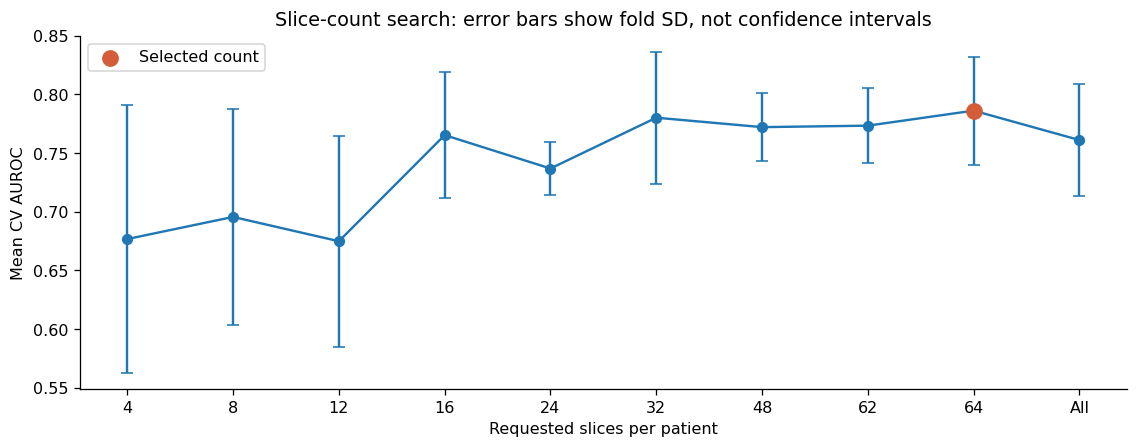

In [15]:
def count_name(count):
    return 'all' if count is None else f'k{int(count):03d}'


def make_cv_folds(train, settings):
    if set(train['split']) != {'train'}:
        raise ValueError('Slice selection accepts the original TRAIN partition only.')
    if train['patient_id'].duplicated().any():
        raise ValueError('CV must split patients, never individual slices.')
    if train['label'].value_counts().min() < settings.cv_folds * 2:
        raise ValueError('Too few patients per class for the requested cross-validation.')
    # All slices of a patient stay together; shared folds permit a controlled count comparison.
    splitter = StratifiedKFold(n_splits=settings.cv_folds, shuffle=True, random_state=settings.seed)
    folds, assignment = [], []
    for fold, (development_idx, score_idx) in enumerate(splitter.split(train, train['label']), 1):
        fit_idx, stop_idx = train_test_split(development_idx,
            test_size=settings.inner_stop_fraction, stratify=train.iloc[development_idx]['label'],
            random_state=settings.seed + 100 * fold)
        parts = [train.iloc[idx].sort_values('patient_id').reset_index(drop=True)
                 for idx in (fit_idx, stop_idx, score_idx)]
        sets = [set(part['patient_id']) for part in parts]
        assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
        assert set.union(*sets) == set(train['patient_id'])
        for role, part in zip(('fit', 'early_stop', 'score'), parts):
            if set(part['label']) != {0, 1}:
                raise ValueError(f'Fold {fold} {role} is missing one class.')
            assignment.extend({'fold': fold, 'role': role, 'patient_id': pid} for pid in part['patient_id'])
        folds.append(parts)
    assignment = pd.DataFrame(assignment)
    scored = assignment.loc[assignment['role'] == 'score', 'patient_id']
    assert set(scored) == set(train['patient_id']) and not scored.duplicated().any()
    return folds, assignment


def select_result(rows, tolerance):
    best_auc = max(row['mean_cv_AUROC'] for row in rows)
    # The predeclared tolerance defines practical near-ties, not significance.
    eligible = [row for row in rows if row['mean_cv_AUROC'] >= best_auc-tolerance-1e-12]
    # Predeclared practical tie-break; this is not a statistical significance test.
    chosen = min(eligible, key=lambda row: (math.inf if row['requested_count'] is None
                                           else row['requested_count'], -row['mean_cv_AUROC']))
    return chosen, best_auc


# Refinement expands the finite candidate set; it does not learn a per-patient count.
def refinement_counts(rows, initial):
    numeric = sorted(k for k in initial if k is not None)
    if len(numeric) < 2:
        return []
    best = max((row for row in rows if row['requested_count'] is not None),
               key=lambda row: (row['mean_cv_AUROC'], -row['requested_count']))['requested_count']
    i = numeric.index(best)
    left, right = numeric[max(0, i-1)], numeric[min(len(numeric)-1, i+1)]
    proposals = {best-2, best+2, (left+best)//2, (best+right)//2}
    return sorted(k for k in proposals if numeric[0] <= k <= numeric[-1] and k not in initial)


def search_slice_counts(train, feature_root, settings, device, output_dir, feature_signature):
    root = Path(output_dir)
    root.mkdir(parents=True, exist_ok=True)
    folds, assignment = make_cv_folds(train, settings)
    identity = {'settings': asdict(settings), 'train_patients': patient_records(train),
                'feature_signature': feature_signature, 'software': VERSIONS,
                'device_type': device.type, 'folds': assignment.to_dict('records')}
    signature = check_identity(root / 'search_identity.json', identity)
    locked_path = root / 'slice_selection.json'
    if locked_path.exists():
        selected = json.loads(locked_path.read_text())
        if selected['search_signature'] != signature:
            raise ValueError('Locked slice search belongs to different data/settings.')
        for filename, checksum in selected['files'].items():
            if sha256_file(root / filename) != checksum:
                raise ValueError(f'Changed search output: {filename}')
        print('Reusing completed slice search:', selected['selected_candidate'])
        return selected, pd.read_csv(root / 'slice_search_results.csv')
    assignment.to_csv(root / 'cv_patient_assignments.csv', index=False)
    store = load_store(train, feature_root, settings.feature_kind, feature_signature)
    rows, fold_rows, oof_rows = [], [], []

    def evaluate_count(count, stage):
        candidate = count_name(count)
        bags, actual_counts = make_bags(train, store, count, settings)
        scores, best_epochs, seconds = [], [], 0.
        for fold, (fit, early_stop, score) in enumerate(folds, 1):
            # Count and fold are part of the job identity, preventing incorrect checkpoint reuse.
            job = object_digest({'search': signature, 'count': count, 'fold': fold})
            print(f'{candidate} | {stage} | fold {fold}/{settings.cv_folds}')
            head, done = fit_head(fit, early_stop, bags, settings, settings.seed+fold,
                                  device, root / 'candidates' / candidate / f'fold_{fold}', job)
            probability = head_probabilities(head, score, bags, device, settings.batch_size)
            auc = float(roc_auc_score(score['label'], probability))
            scores.append(auc)
            best_epochs.append(done['best_epoch'])
            seconds += done['seconds']
            fold_rows.append({'candidate': candidate, 'fold': fold, 'score_AUROC': auc,
                              'best_epoch': done['best_epoch'], 'fit_patients': len(fit),
                              'early_stop_patients': len(early_stop), 'score_patients': len(score)})
            oof_rows.extend({'candidate': candidate, 'fold': fold, 'patient_id': pid,
                             'label': int(label), 'IDH_mutant_score': float(p)}
                            for pid, label, p in zip(score['patient_id'], score['label'], probability))
            del head
        row = {'candidate': candidate, 'requested_count': count, 'stage': stage,
               'mean_cv_AUROC': float(np.mean(scores)), 'std_fold_AUROC': float(np.std(scores, ddof=1)),
               'min_actual_slices': int(actual_counts.min()), 'mean_actual_slices': float(actual_counts.mean()),
               'max_actual_slices': int(actual_counts.max()),
               'median_best_epoch': max(1, int(np.floor(np.median(best_epochs)+.5))),
               'total_fit_seconds': seconds}
        rows.append(row)
        pd.DataFrame(rows).to_csv(root / 'slice_search_results.csv', index=False)
        pd.DataFrame(fold_rows).to_csv(root / 'slice_search_folds.csv', index=False)
        pd.DataFrame(oof_rows).to_csv(root / 'cv_predictions.csv', index=False)
        print(f'{candidate}: CV AUROC {row["mean_cv_AUROC"]:.4f} '
              f'(fold SD {row["std_fold_AUROC"]:.4f})')

    for count in settings.counts:
        evaluate_count(count, 'initial')
    if settings.refine:
        for count in refinement_counts(rows, settings.counts):
            evaluate_count(count, 'local_refinement')
    chosen, raw_best = select_result(rows, settings.near_tie_auc)
    selected = {'search_signature': signature, 'selected_count': chosen['requested_count'],
                'selected_candidate': chosen['candidate'], 'selected_cv_AUROC': chosen['mean_cv_AUROC'],
                'best_tested_cv_AUROC': raw_best, 'near_tie_auc': settings.near_tie_auc,
                'final_training_epochs': chosen['median_best_epoch'],
                'feature_kind': settings.feature_kind,
                'slice_range': [settings.lower_fraction, settings.upper_fraction],
                'tested_counts': [r['requested_count'] for r in rows],
                'selection_metric': 'mean patient-fold AUROC',
                'test_used_for_selection': False, 'validation_used_for_selection': False,
                'files': {name: sha256_file(root / name) for name in
                          ('slice_search_results.csv', 'slice_search_folds.csv',
                           'cv_predictions.csv', 'cv_patient_assignments.csv')}}
    json_write(locked_path, selected)
    return selected, pd.DataFrame(rows)


def plot_slice_search(results, selection, root):
    frame = results.copy()
    frame['_sort'] = frame['requested_count'].fillna(np.inf)
    frame = frame.sort_values('_sort')
    labels = [str(int(k)) if pd.notna(k) else 'All' for k in frame['requested_count']]
    x = np.arange(len(frame))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.errorbar(x, frame['mean_cv_AUROC'], yerr=frame['std_fold_AUROC'], fmt='o-', capsize=4)
    winner = int(np.flatnonzero(frame['candidate'].to_numpy() == selection['selected_candidate'])[0])
    ax.scatter(x[winner], frame.iloc[winner]['mean_cv_AUROC'], color='#d45c38', s=90, zorder=5,
               label='Selected count')
    ax.set(xticks=x, xticklabels=labels, xlabel='Requested slices per patient', ylabel='Mean CV AUROC',
           title='Slice-count search: error bars show fold SD, not confidence intervals')
    ax.legend()
    fig.tight_layout()
    fig.savefig(Path(root) / 'slice_search_curve.png', dpi=150)
    plt.show()


if RUN_SEARCH:
    selection, search_results = search_slice_counts(partitions['train'], FEATURE_ROOT, search_cfg,
        DEVICE, SEARCH_ROOT, FEATURE_SIGNATURE)
    display(search_results.sort_values('mean_cv_AUROC', ascending=False).reset_index(drop=True))
    print('SELECTED SLICE COUNT:', 'all' if selection['selected_count'] is None else selection['selected_count'])
    print('Final head training epochs (from inner-fold stopping):', selection['final_training_epochs'])
    plot_slice_search(search_results, selection, SEARCH_ROOT)


## 12. Final fitting and validation-only decision threshold

A new head is fitted on all original training patients using the selected count and epoch duration. Validation patients do not update its parameters; their scores choose a decision threshold that maximizes balanced accuracy.

$$\text{balanced accuracy}=\tfrac12(\text{mutant sensitivity}+\text{wildtype specificity}).$$

This gives both classes equal importance. Ordinary accuracy weights them according to prevalence, so its maximizing threshold can differ. Equal balanced-accuracy values prefer the threshold nearest 0.5. The selected threshold, model checksum, and preprocessing identity are saved before test scoring.

The sigmoid output is an uncalibrated score. A score of 0.8 is not established as an 80% clinical chance of mutation. Validation metrics here are development results because the threshold was selected on these patients.

In [16]:
def summarize_predictions(labels, probability, threshold):
    labels = np.asarray(labels, dtype=int)
    probability = np.asarray(probability, dtype=float)
    predicted = (probability >= threshold).astype(int)
    # Class order [0,1] makes mutant the positive class consistently.
    tn, fp, fn, tp = confusion_matrix(labels, predicted, labels=[0, 1]).ravel()
    return {'patients': int(len(labels)), 'IDH_mutant_patients': int(labels.sum()),
            'AUROC_ranking': float(roc_auc_score(labels, probability)),
            'accuracy_fraction_correct': float(accuracy_score(labels, predicted)),
            'balanced_accuracy': float(balanced_accuracy_score(labels, predicted)),
            'sensitivity_mutant': float(tp/(tp+fn)), 'specificity_wildtype': float(tn/(tn+fp)),
            'average_precision': float(average_precision_score(labels, probability)),
            'F1_mutant': float(f1_score(labels, predicted, zero_division=0)),
            'log_loss': float(log_loss(labels, np.clip(probability, 1e-7, 1-1e-7), labels=[0, 1])),
            'Brier_score': float(brier_score_loss(labels, probability)), 'threshold': float(threshold),
            'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}


# Threshold selection uses validation labels only, after count and duration are chosen.
def choose_validation_threshold(labels, probability):
    rows = [{'threshold': float(t),
             'balanced_accuracy': float(balanced_accuracy_score(labels, probability >= t))}
            for t in np.linspace(.05, .95, 181)]
    table = pd.DataFrame(rows)
    best = table.loc[table['balanced_accuracy'] >= table['balanced_accuracy'].max()-1e-12].copy()
    best['distance_to_half'] = (best['threshold']-.5).abs()
    threshold = float(best.sort_values(['distance_to_half', 'threshold']).iloc[0]['threshold'])
    return threshold, table


def fit_final_model(train, validation, feature_root, settings, device, output_dir,
                    feature_signature, feature_identity):
    root = Path(output_dir)
    selected = json.loads((root / 'slice_selection.json').read_text())
    search_identity = json.loads((root / 'search_identity.json').read_text())
    if (canonical_json(asdict(settings)) != search_identity['identity']['settings']
            or canonical_json(patient_records(train)) != search_identity['identity']['train_patients']
            or feature_signature != search_identity['identity']['feature_signature']
            or selected['search_signature'] != search_identity['signature']):
        raise ValueError('The locked slice selection does not match the final training configuration.')
    if set(train['split']) != {'train'} or set(validation['split']) != {'validation'}:
        raise ValueError('Final fitting accepts the saved training and validation partitions only.')
    if set(train['patient_id']) & set(validation['patient_id']):
        raise ValueError('Patient overlap between training and validation.')
    identity = {'selection_sha256': sha256_file(root / 'slice_selection.json'),
                'train': patient_records(train), 'validation': patient_records(validation),
                'feature_signature': feature_signature}
    signature = check_identity(root / 'final_identity.json', identity)
    manifest_path = root / 'prediction_manifest.json'
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        if manifest['final_signature'] != signature or sha256_file(root / manifest['head_file']) != manifest['head_sha256']:
            raise ValueError('The locked classifier changed on disk.')
        print('Reusing the locked final classifier and validation threshold.')
        return manifest
    store = load_store(pd.concat([train, validation]), feature_root, selected['feature_kind'], feature_signature)
    bags, _ = make_bags(pd.concat([train, validation]), store, selected['selected_count'], settings)
    head, done = fit_head(train, None, bags, settings, settings.seed+10000, device,
                          root / 'final_model', signature, fixed_epochs=selected['final_training_epochs'])
    # The fresh final head has finished fitting before it sees validation scores.
    probability = head_probabilities(head, validation, bags, device, settings.batch_size)
    threshold, threshold_table = choose_validation_threshold(validation['label'], probability)
    threshold_table.to_csv(root / 'validation_thresholds.csv', index=False)
    predictions = validation[['patient_id', 'label']].copy()
    predictions['IDH_mutant_score'] = probability
    predictions['predicted_label'] = (probability >= threshold).astype(int)
    predictions.to_csv(root / 'validation_predictions.csv', index=False)
    validation_metrics = summarize_predictions(validation['label'], probability, threshold)
    pd.DataFrame([validation_metrics]).to_csv(root / 'validation_metrics.csv', index=False)
    extraction_config = json.loads((Path(feature_root) / 'extraction_config.json').read_text())
    manifest = {'final_signature': signature, 'feature_signature': feature_signature,
                'feature_identity': feature_identity, 'extraction_config': extraction_config,
                'selected_count': selected['selected_count'], 'selected_candidate': selected['selected_candidate'],
                'feature_kind': selected['feature_kind'], 'slice_range': selected['slice_range'],
                'head_file': 'final_model/head.pt', 'head_sha256': done['head_sha256'],
                'training_epochs': selected['final_training_epochs'], 'threshold': threshold,
                'threshold_objective': 'validation balanced accuracy', 'positive_label': 'IDH mutant',
                'classnames': ['IDH wildtype', 'IDH mutant'], 'score_is_calibrated': False,
                'train_prevalence': float(train['label'].mean()),
                'train_patient_ids': train['patient_id'].tolist(),
                'validation_patient_ids': validation['patient_id'].tolist(),
                'test_used_for_training_or_selection': False}
    # The prediction manifest locks threshold and model identities before test evaluation.
    json_write(manifest_path, manifest)  # Write the prediction lock only after fitting and threshold selection.
    del head, store, bags
    print('Locked threshold:', round(threshold, 4), '| objective: validation balanced accuracy')
    print('Validation metrics below were used for threshold selection; they are not test results.')
    display(pd.DataFrame([validation_metrics]))
    return manifest


if RUN_SEARCH:
    prediction_manifest = fit_final_model(partitions['train'], partitions['validation'], FEATURE_ROOT,
        search_cfg, DEVICE, SEARCH_ROOT, FEATURE_SIGNATURE, FEATURE_IDENTITY)


Load verified slice features:   0%|          | 0/420 [00:00<?, ?it/s]

final_model:   0%|          | 0/11 [00:00<?, ?it/s]

Locked threshold: 0.635 | objective: validation balanced accuracy
Validation metrics below were used for threshold selection; they are not test results.


,patients,IDH_mutant_patients,AUROC_ranking,accuracy_fraction_correct,balanced_accuracy,sensitivity_mutant,specificity_wildtype,average_precision,F1_mutant,log_loss,Brier_score,threshold,TN,FP,FN,TP
0,75,16,0.852754,0.866667,0.824153,0.75,0.898305,0.767211,0.705882,0.447015,0.137907,0.635,53,6,4,12


## 13. Evaluation of the locked patient classifier

The test cell loads the saved head, slice count, and threshold. It verifies patient separation and output identities. Existing completed results can be displayed again without changing the experiment.

**AUROC** measures ranking across thresholds; **accuracy** measures correct calls at the locked threshold. **Sensitivity** is the fraction of mutants detected; **specificity** is the fraction of wildtype patients correctly called wildtype. The confusion matrix reports the underlying counts. A constant training-prevalence baseline exposes how imbalance can make ordinary accuracy look high without detecting mutants.

The existing stratified patient bootstrap gives an AUROC interval conditional on this fitted pipeline and observed class counts. It does not include retraining or model-selection uncertainty. The added evaluation below uses saved predictions and never retunes the threshold or classifier.

Earlier test results have already been viewed in this project. Repeated design decisions informed by those results make the overall comparison exploratory; an independent cohort would strengthen confirmation.

Load verified slice features:   0%|          | 0/75 [00:00<?, ?it/s]

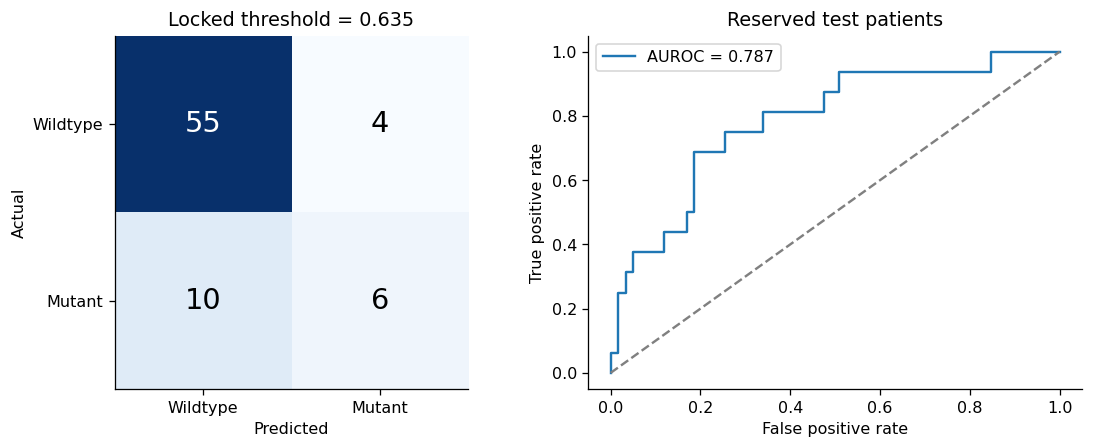

Accuracy (fraction correct): 81.3%
AUROC (ranking measure): 0.7871


,patients,IDH_mutant_patients,AUROC_ranking,accuracy_fraction_correct,balanced_accuracy,sensitivity_mutant,specificity_wildtype,average_precision,F1_mutant,log_loss,Brier_score,threshold,TN,FP,FN,TP,model,AUROC_CI_low,AUROC_CI_high
0,75,16,0.787076,0.813333,0.653602,0.375,0.932203,0.544733,0.461538,0.478232,0.149860,0.635,55,4,10,6,Frozen DINOv2 + selected slices,0.658898,0.899391
1,75,16,0.500000,0.786667,0.500000,0.000,1.000000,0.213333,0.000000,0.518512,0.167879,0.500,59,0,16,0,Training-prevalence baseline,0.500000,0.500000


In [17]:
def load_locked_head(root, device):
    root = Path(root)
    manifest = json.loads((root / 'prediction_manifest.json').read_text())
    if sha256_file(root / manifest['head_file']) != manifest['head_sha256']:
        raise ValueError('The locked classifier checksum failed.')
    return load_head(root / manifest['head_file'], device), manifest


def bootstrap_auc(labels, scores, repeats, seed):
    labels, scores = np.asarray(labels), np.asarray(scores)
    negative, positive = np.flatnonzero(labels == 0), np.flatnonzero(labels == 1)
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(repeats):
        # Resample patients within each class; keep the fitted model and threshold fixed.
        idx = np.concatenate([rng.choice(negative, len(negative), replace=True),
                              rng.choice(positive, len(positive), replace=True)])
        values.append(roc_auc_score(labels[idx], scores[idx]))
    return np.percentile(values, [2.5, 97.5]).tolist()


def evaluate_locked_test(test, feature_root, output_dir, settings, device):
    root = Path(output_dir)
    head, manifest = load_locked_head(root, device)
    if set(test['split']) != {'test'} or test['patient_id'].duplicated().any():
        raise ValueError('Final evaluation requires the saved test partition, one row per patient.')
    # A test ID appearing in training or threshold selection would invalidate this evaluation.
    used = set(manifest['train_patient_ids']) | set(manifest['validation_patient_ids'])
    if used & set(test['patient_id']):
        raise ValueError('A test patient was used in development.')
    identity = {'prediction_lock_sha256': sha256_file(root / 'prediction_manifest.json'),
                'test': patient_records(test), 'bootstrap_repeats': settings.bootstrap_repeats}
    signature = check_identity(root / 'test_identity.json', identity)
    complete = root / 'test_evaluation_complete.json'
    if complete.exists():
        done = json.loads(complete.read_text())
        if done['signature'] != signature:
            raise ValueError('Saved test results belong to a different locked experiment.')
        for name, checksum in done['files'].items():
            if sha256_file(root / name) != checksum:
                raise ValueError('Saved test output changed.')
        print('Reusing saved test results; slice search and threshold were not rerun.')
        return pd.read_csv(root / 'test_metrics.csv')
    store = load_store(test, feature_root, manifest['feature_kind'], manifest['feature_signature'])
    fixed = replace(settings, lower_fraction=manifest['slice_range'][0], upper_fraction=manifest['slice_range'][1])
    bags, _ = make_bags(test, store, manifest['selected_count'], fixed)
    # Only forward inference occurs here; no parameter updates or threshold search.
    scores = head_probabilities(head, test, bags, device, settings.batch_size)
    predicted = test[['patient_id', 'label']].copy()
    predicted['IDH_mutant_score'] = scores
    predicted['predicted_label'] = (scores >= manifest['threshold']).astype(int)
    predicted.to_csv(root / 'test_predictions.csv', index=False)
    model_metrics = summarize_predictions(test['label'], scores, manifest['threshold'])
    low, high = bootstrap_auc(test['label'], scores, settings.bootstrap_repeats, settings.seed+50000)
    model_metrics.update(model='Frozen DINOv2 + selected slices', AUROC_CI_low=low, AUROC_CI_high=high)
    # The baseline score is derived from training prevalence, not test prevalence.
    baseline = summarize_predictions(test['label'], np.full(len(test), manifest['train_prevalence']), .5)
    baseline.update(model='Training-prevalence baseline', AUROC_CI_low=.5, AUROC_CI_high=.5)
    metrics = pd.DataFrame([model_metrics, baseline])
    metrics.to_csv(root / 'test_metrics.csv', index=False)
    cm = confusion_matrix(test['label'], predicted['predicted_label'], labels=[0, 1])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                         color='white' if cm[i, j] > cm.max()/2 else 'black')
    axes[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Wildtype', 'Mutant'],
                yticklabels=['Wildtype', 'Mutant'], xlabel='Predicted', ylabel='Actual',
                title=f'Locked threshold = {manifest["threshold"]:.3f}')
    fpr, tpr, _ = roc_curve(test['label'], scores)
    axes[1].plot(fpr, tpr, label=f'AUROC = {model_metrics["AUROC_ranking"]:.3f}')
    axes[1].plot([0, 1], [0, 1], '--', color='gray')
    axes[1].set(xlabel='False positive rate', ylabel='True positive rate', title='Reserved test patients')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(root / 'test_results.png', dpi=150)
    plt.show()
    json_write(complete, {'signature': signature, 'files': {name: sha256_file(root / name) for name in
                           ('test_predictions.csv', 'test_metrics.csv', 'test_results.png')}})
    print(f'Accuracy (fraction correct): {model_metrics["accuracy_fraction_correct"]:.1%}')
    print(f'AUROC (ranking measure): {model_metrics["AUROC_ranking"]:.4f}')
    return metrics


if RUN_FINAL_TEST:
    test_metrics = evaluate_locked_test(partitions['test'], FEATURE_ROOT, SEARCH_ROOT, search_cfg, DEVICE)
    display(test_metrics)
else:
    print('Test evaluation is off. Set RUN_FINAL_TEST=True only after locking the experiment.')


### Additional evaluation: predictive values, precision–recall, and uncertainty

Precision asks how many predicted mutants are truly mutant; negative predictive value asks how many predicted wildtype patients are truly wildtype. Both depend on prevalence. The precision–recall curve focuses on detection of the positive class; its horizontal reference is the observed test mutant fraction, used only for interpretation.

Wilson intervals describe uncertainty in proportions such as accuracy, sensitivity, specificity, and precision. They condition on the saved predictions and independent-patient assumption; they do not include retraining or selection variability. A reliability plot compares average scores with observed mutant fractions in equal-width bins. With few patients, bins can be sparse; the plot diagnoses score behavior without calibrating the model.

All added outputs read `test_predictions.csv` and the locked manifest. No new threshold is selected and no test result is used to update the model. Comparisons to prior rounded results require confirming identical test patients and experimental conditions.

,metric,numerator,denominator,estimate,Wilson_95_low,Wilson_95_high
0,Accuracy,61,75,0.813333,0.710714,0.885419
1,Mutant sensitivity / recall,6,16,0.375000,0.184812,0.613590
2,Wildtype specificity,55,59,0.932203,0.838245,0.973321
3,Mutant precision / PPV,6,10,0.600000,0.312674,0.831820
4,Wildtype negative predictive value,55,65,0.846154,0.739447,0.914229


Average precision: 0.5447; observed test mutant fraction: 21.3%
Test prevalence is a descriptive PR reference; it was not used to fit the baseline.


,bin_lower,bin_upper,patients,mutants,mean_score,observed_mutant_fraction,Wilson_95_low,Wilson_95_high
0,0.0,0.2,53,5,0.050942,0.094340,0.040973,0.202537
1,0.2,0.4,5,4,0.290115,0.800000,0.375535,0.963776
2,0.4,0.6,7,1,0.463029,0.142857,0.025680,0.513128
3,0.6,0.8,2,1,0.725604,0.500000,0.094531,0.905469
4,0.8,1.0,8,5,0.888656,0.625000,0.305742,0.863156


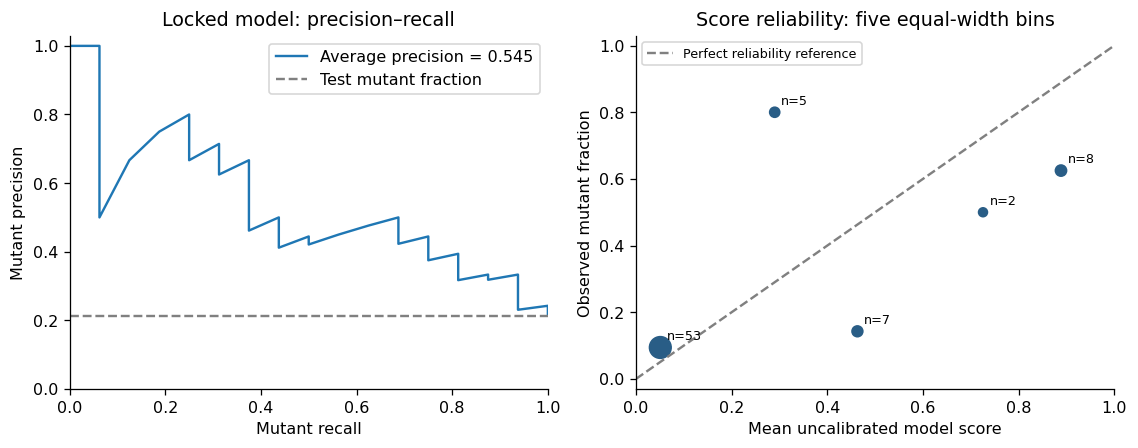

Additional evaluation saved: /kaggle/working/radiogenomics_frozen/idh_dinov2_auto_slices_v1/presentation_evaluation


In [18]:
def wilson_proportion_interval(successes, total, z=1.959963984540054):
    # A bounded interval for a binomial proportion, including small/zero counts.
    if total == 0:
        return np.nan, np.nan
    proportion = successes / total
    denominator = 1 + z*z/total
    center = (proportion + z*z/(2*total)) / denominator
    half = z * np.sqrt(proportion*(1-proportion)/total + z*z/(4*total*total)) / denominator
    return max(0., center-half), min(1., center+half)


def presentation_extra_evaluation(experiment_root):
    root = Path(experiment_root)
    predictions = pd.read_csv(root / 'test_predictions.csv', dtype={'patient_id': str})
    manifest = json.loads((root / 'prediction_manifest.json').read_text())
    labels = predictions['label'].to_numpy(dtype=int)
    scores = predictions['IDH_mutant_score'].to_numpy(dtype=float)
    called = predictions['predicted_label'].to_numpy(dtype=int)
    # Check the saved calls against the existing lock; never search test thresholds.
    assert np.array_equal(called, (scores >= manifest['threshold']).astype(int))
    tn, fp, fn, tp = confusion_matrix(labels, called, labels=[0, 1]).ravel()
    out = root / 'presentation_evaluation'
    out.mkdir(parents=True, exist_ok=True)
    definitions = [
        ('Accuracy', tp+tn, len(labels)),
        ('Mutant sensitivity / recall', tp, tp+fn),
        ('Wildtype specificity', tn, tn+fp),
        ('Mutant precision / PPV', tp, tp+fp),
        ('Wildtype negative predictive value', tn, tn+fn),
    ]
    rows = []
    for metric, numerator, denominator in definitions:
        low, high = wilson_proportion_interval(int(numerator), int(denominator))
        rows.append({'metric': metric, 'numerator': int(numerator), 'denominator': int(denominator),
                     'estimate': float(numerator/denominator) if denominator else np.nan,
                     'Wilson_95_low': low, 'Wilson_95_high': high})
    intervals = pd.DataFrame(rows)
    intervals.to_csv(out / 'predictive_values_and_intervals.csv', index=False)
    display(intervals)
    precision, recall, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    observed_prevalence = float(labels.mean())
    print(f'Average precision: {ap:.4f}; observed test mutant fraction: {observed_prevalence:.1%}')
    print('Test prevalence is a descriptive PR reference; it was not used to fit the baseline.')

    # Equal-width score bins show reliability without fitting a calibration model.
    edges = np.linspace(0., 1., 6)
    bin_ids = np.clip(np.searchsorted(edges, scores, side='right')-1, 0, len(edges)-2)
    reliability = []
    for index in range(len(edges)-1):
        members = bin_ids == index
        count = int(members.sum())
        positives = int(labels[members].sum())
        low, high = wilson_proportion_interval(positives, count)
        reliability.append({'bin_lower': float(edges[index]), 'bin_upper': float(edges[index+1]),
            'patients': count, 'mutants': positives,
            'mean_score': float(scores[members].mean()) if count else np.nan,
            'observed_mutant_fraction': float(positives/count) if count else np.nan,
            'Wilson_95_low': low, 'Wilson_95_high': high})
    bins = pd.DataFrame(reliability)
    bins.to_csv(out / 'score_reliability_bins.csv', index=False)
    display(bins)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(recall, precision, label=f'Average precision = {ap:.3f}')
    axes[0].axhline(observed_prevalence, linestyle='--', color='gray', label='Test mutant fraction')
    axes[0].set(xlabel='Mutant recall', ylabel='Mutant precision', title='Locked model: precision–recall',
                xlim=(0, 1), ylim=(0, 1.03))
    axes[0].legend()
    nonempty = bins.loc[bins['patients'].gt(0)]
    axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Perfect reliability reference')
    axes[1].scatter(nonempty['mean_score'], nonempty['observed_mutant_fraction'],
                    s=25+3*nonempty['patients'], color='#295d86')
    for row in nonempty.to_dict('records'):
        axes[1].annotate(f'n={row["patients"]}', (row['mean_score'], row['observed_mutant_fraction']),
                         xytext=(4, 5), textcoords='offset points', fontsize=8)
    axes[1].set(xlabel='Mean uncalibrated model score', ylabel='Observed mutant fraction',
                title='Score reliability: five equal-width bins', xlim=(0, 1), ylim=(-.03, 1.03))
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(out / 'precision_recall_and_reliability.png', dpi=150)
    plt.show()
    print('Additional evaluation saved:', out)


if RUN_FINAL_TEST:
    presentation_extra_evaluation(SEARCH_ROOT)
else:
    print('Additional evaluation skipped because final test evaluation is disabled.')

## 14. Applying the saved pipeline to a patient

Prediction reproduces training-time preprocessing, frozen encoding, selected sampling interval/count, attention pooling, and the locked threshold. The default demonstration uses a known validation patient and shows its label only after prediction; it demonstrates the workflow rather than independent generalization.

New patients require registered, consistently skull-stripped FLAIR, T1c, and T2 NIfTI files. Raw hospital images are not automatically registered or skull-stripped here. Encoder and feature identities are checked to prevent incompatible representations from reaching the trained head.

```python
result = predict_new_patient(
    {'FLAIR': '/kaggle/input/new-patient/FLAIR.nii.gz',
     'T1c': '/kaggle/input/new-patient/T1c.nii.gz',
     'T2': '/kaggle/input/new-patient/T2.nii.gz'},
    SEARCH_ROOT, patient_id='new_patient')
display(pd.Series(result))
```

The score, class, physical slice positions, and pooling weights describe the prediction. Differences in population, acquisition, preprocessing, or inference precision can affect transfer.

In [19]:
def predict_feature_bag(vectors, coordinates, head, manifest, device, patient_id):
    # Apply the saved count and interval instead of choosing them anew for this patient.
    chosen, z_mm = select_cached_slices(vectors, coordinates, manifest['selected_count'], *manifest['slice_range'])
    tensor = torch.from_numpy(np.ascontiguousarray(chosen, dtype=np.float32)).unsqueeze(0).to(device)
    mask = torch.ones(tensor.shape[:2], dtype=torch.bool, device=device)
    head.eval()
    with torch.inference_mode():
        logit, attention = head(tensor, mask, return_attention=True)
        score = float(logit.sigmoid().item())
    return {'patient_id': str(patient_id), 'IDH_mutant_score_uncalibrated': score,
            'threshold': manifest['threshold'],
            'predicted_class': manifest['classnames'][int(score >= manifest['threshold'])],
            'requested_slice_count': manifest['selected_count'], 'actual_selected_slices': len(chosen),
            'selected_z_mm': z_mm.tolist(), 'slice_attention_weights': attention[0].cpu().tolist()}


def predict_cached_patient(record, feature_root, experiment_root, device=None):
    device = torch.device(device) if device is not None else DEVICE
    head, manifest = load_locked_head(experiment_root, device)
    vectors, coordinates = load_patient_features(record, feature_root, manifest['feature_kind'])
    if str(coordinates['feature_signature'].item()) != manifest['feature_signature']:
        raise ValueError('Features do not match the classifier preprocessing/encoder.')
    return predict_feature_bag(vectors, coordinates, head, manifest, device, record['patient_id'])


def predict_new_patient(modality_paths, experiment_root, patient_id='new_study', device=None):
    device = torch.device(device) if device is not None else DEVICE
    head, manifest = load_locked_head(experiment_root, device)
    config_values = dict(manifest['extraction_config'])
    config_values['modalities'] = tuple(config_values['modalities'])
    # Reconstruct the image preparation settings that produced the training cache.
    config = ExtractionConfig(**config_values)
    if set(modality_paths) != set(config.modalities):
        raise ValueError('Supply exactly FLAIR, T1c, and T2 NIfTI paths.')
    frozen = FrozenDINOv2(config).to(device).eval()
    if model_digest(frozen) != manifest['feature_identity']['model_state_sha256']:
        raise ValueError('Pretrained encoder weights differ from the training cache.')
    precision = 'cuda_float16_autocast' if config.use_mixed_precision and device.type == 'cuda' else 'float32'
    if precision != manifest['feature_identity']['precision']:
        warnings.warn('Inference precision differs from extraction; small numerical differences are possible.')
    prepared = prepare_volume(modality_paths, config)
    cls, patch = encode_volume(prepared, frozen, config, device)
    vectors = {'cls': cls, 'patch_mean': patch, 'concat': np.concatenate([cls, patch], axis=1)}[manifest['feature_kind']]
    coordinates = {'slice_fraction': prepared['fractions'], 'slice_z_mm': prepared['z_mm']}
    result = predict_feature_bag(vectors, coordinates, head, manifest, device, patient_id)
    del frozen, head
    return result


if RUN_DEMO:
    demo_patient = partitions['validation'].iloc[0]
    demo_result = predict_cached_patient(demo_patient, FEATURE_ROOT, SEARCH_ROOT)
    display(pd.Series({k: v for k, v in demo_result.items()
                       if k not in {'selected_z_mm', 'slice_attention_weights'}}).to_frame('prediction'))
    print('Known validation-patient label:', ['IDH wildtype', 'IDH mutant'][int(demo_patient['label'])])
    print('This demonstration is not an independent test of performance.')


,prediction
patient_id,UCSF-PDGM-0021
IDH_mutant_score_uncalibrated,0.97117
threshold,0.635
predicted_class,IDH mutant
requested_slice_count,64
actual_selected_slices,64


Known validation-patient label: IDH mutant
This demonstration is not an independent test of performance.


## 15. Reproducible export and evidence for the presentation

The archive preserves features, patient splits, provenance, fold assignments, fitting histories, selected settings, locked weights/threshold, and completed evaluation. It excludes source MRI volumes and pretrained encoder weights. Save a Kaggle version with outputs and retain the ZIP to reproduce the experiment.

| Evidence | Saved output |
|---|---|
| Cohort composition and raw training image audit | `presentation_data_analysis/` in the experiment directory |
| Count versus cross-validation performance | `slice_search_results.csv`, `slice_search_curve.png` |
| Selection and training duration | `slice_selection.json` |
| Patient separation | `cv_patient_assignments.csv` |
| Locked model and threshold | `prediction_manifest.json` |
| Original test metrics and predictions | `test_metrics.csv`, `test_predictions.csv`, `test_results.png` |
| Additional predictive values and uncertainty | `presentation_evaluation/` |

The new diagnostic folders are included by the existing recursive experiment export. They contain descriptions and evaluation only; fitting code and hyperparameters are unchanged.

In [20]:
def export_experiment(feature_root, experiment_root, archive_path):
    feature_root, experiment_root, archive_path = map(Path, (feature_root, experiment_root, archive_path))
    table, summary, _ = load_feature_manifest(feature_root)
    if not (experiment_root / 'prediction_manifest.json').exists():
        raise RuntimeError('Finish slice selection and final classifier fitting before exporting.')
    readme = experiment_root / 'README.txt'
    readme.write_text(
        'Frozen DINOv2 IDH slice-count experiment\n'
        'Labels: 0 = IDH wildtype; 1 = IDH mutant. Inputs: FLAIR, T1c, T2 images only.\n'
        'All nonempty axial slices are cached. Counts are selected by patient-level CV on training patients.\n'
        'Inner patient subsets control early stopping; outer fold patients score each count.\n'
        'Final fitting uses the original training patients and the CV-derived epoch count.\n'
        'The original validation patients select the balanced-accuracy decision threshold.\n'
        'Test patients are used only after the prediction manifest is locked.\n'
        'AUROC is a ranking score. Accuracy is the fraction of correctly classified patients.\n'
        'Slice search does not guarantee an improvement or a universal best slice count.\n'
        'Restore the feature folder, set FEATURE_PACK_DIR to it, and RUN_EXTRACTION=False to reuse features.\n'
        'Restore this experiment folder to SEARCH_ROOT to reuse completed fold fits and results.\n'
        'Raw MRI volumes and pretrained DINOv2 weights are not included in this archive.\n')
    feature_files = [p for p in feature_root.iterdir() if p.is_file() and p.suffix in {'.json', '.csv', '.png', '.txt'}]
    for row in table.to_dict('records'):
        path = feature_root / row['feature_file']
        if sha256_file(path) != row['feature_sha256']:
            raise ValueError(f'Feature checksum failed before export: {row["patient_id"]}')
        feature_files.extend([path, path.with_suffix('.json')])
    archive_path.parent.mkdir(parents=True, exist_ok=True)
    temporary = archive_path.with_name(archive_path.name+'.part')
    # ZIP_STORED avoids repeatedly compressing already compressed feature arrays.
    with zipfile.ZipFile(temporary, 'w', compression=zipfile.ZIP_STORED, allowZip64=True) as archive:
        for path in sorted(set(feature_files)):
            archive.write(path, arcname=str(Path('idh_dinov2_frozen_v1') / path.relative_to(feature_root)))
        # Recursive export also includes the added data-analysis and evaluation folders.
        for path in sorted(experiment_root.rglob('*')):
            if path.is_file() and path.suffix in {'.json', '.csv', '.png', '.txt', '.pt'}:
                archive.write(path, arcname=str(Path(experiment_root.name) / path.relative_to(experiment_root)))
    temporary.replace(archive_path)
    return archive_path


if CREATE_ARCHIVE and (RUN_SEARCH or RUN_FINAL_TEST):
    archive = export_experiment(FEATURE_ROOT, SEARCH_ROOT, ARCHIVE_ROOT / f'{search_cfg.experiment_name}.zip')
    print('Complete experiment archive:', archive)
    print('Archive size (MB):', round(archive.stat().st_size/1e6, 1))
    from IPython.display import FileLink
    display(FileLink(str(archive)))


Complete experiment archive: /kaggle/working/idh_dinov2_auto_slices_v1.zip
Archive size (MB): 221.1


/kaggle/working/idh_dinov2_auto_slices_v1.zip

## Mathematical interpretation, conclusions, and limits

The experiment studies the composed predictor

$$X\longmapsto\{f_\theta(X_i):i\in S_k(X)\}\longmapsto\hat p,$$

where f_theta is a frozen encoder, S_k selects slices using image support and physical position, and the fitted gated head maps a bag to a patient score. Changing k changes the evidence presented to the head, not its parameter count. More slices can add signal, redundancy, or irrelevant anatomy; less sampling can miss useful regions. Generalization must be measured, not assumed.

The gated head pools a set and does not explicitly encode slice order. Physical position guides selection, but it is not appended as a learned feature. DINOv2's within-image positional information differs from between-slice 3D context. A later experiment could investigate spatial context under matched patient splits.

**Interpretation of prior reported numbers:** about 81% accuracy is higher than the earlier screenshot's 62.67%, whereas about 0.79 AUROC is slightly below its 0.8072. If the same 75 patients apply, the earlier always-wildtype baseline was 78.67% accurate. Class-specific errors and intervals are needed to judge useful improvement. The previous encoder was partly fine-tuned and this encoder is frozen, so a cross-notebook difference cannot be attributed to slice count alone.

Limits include cohort size, class imbalance, natural-image pretraining, potential acquisition/site effects, and exploratory reuse of a viewed test partition. This notebook does not demonstrate that transformers outperform CNNs or establish clinical validity. Matched backbone comparisons, one-change-at-a-time ablations, repeated seeds, and independent cohorts can answer stronger questions.

### References
- [DINOv2 paper](https://arxiv.org/abs/2304.07193) and [official checkpoint](https://huggingface.co/facebook/dinov2-small).
- [Pinned Transformers implementation](https://huggingface.co/docs/transformers/v4.44.2/model_doc/dinov2).
- [Ilse et al., Attention-based Deep Multiple Instance Learning](https://proceedings.mlr.press/v80/ilse18a.html).
- [UCSF-PDGM collection](https://www.cancerimagingarchive.net/collection/ucsf-pdgm/) and [structural mirror](https://huggingface.co/datasets/MedOtter/UCSF-PDGM).
- [Stratified patient fold API](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html).
- [Hyperparameter selection and reserved testing](https://scikit-learn.org/stable/modules/grid_search.html).